# Packages

In [2]:
%pip install sklearn
%pip install pandas
%pip install numpy
%pip install xgboost
%pip install matplotlib
%pip install seaborn
%pip install xgboost
%pip install cleanlab
%pip install ipywidgets
%pip install imbalanced-learn
%pip install statsmodels
%pip install shap
%pip install prophet
%pip install plotly
%pip install tensorflow
%pip install scipy
%pip install statsforecast
%pip install utilsforecast


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Imports

In [3]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from cleanlab.filter import find_label_issues
from imblearn.under_sampling import RandomUnderSampler
from matplotlib import cm

from sklearn.cluster import KMeans
from sklearn.decomposition import (
    PCA,
    TruncatedSVD
)
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest, RandomForestClassifier, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    accuracy_score,
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    StratifiedKFold,
    TimeSeriesSplit,
    cross_val_predict,
    train_test_split
)
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
    Binarizer,
    FunctionTransformer,
    OneHotEncoder
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stl.mstl import MSTL
import shap

from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, LSTM, Conv1D,
                                     GlobalMaxPooling1D, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

from statsforecast.models import (
    AutoARIMA,
    Naive,
    HistoricAverage,
    WindowAverage,
    SeasonalNaive,
)
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from keras import Input
from utilsforecast.plotting import plot_series


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Functions

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#trigonometric-features

In [4]:
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))


def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

In [5]:
def sklearnEvaluate(model, X, y, cv, model_prop=None, model_step=None):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error"],
        return_estimator=model_prop is not None,
    )
    if model_prop is not None:
        if model_step is not None:
            values = [
                getattr(m[model_step], model_prop) for m in cv_results["estimator"]
            ]
        else:
            values = [getattr(m, model_prop) for m in cv_results["estimator"]]
        print(f"Mean model.{model_prop} = {np.mean(values)}")
    mae = -cv_results["test_neg_mean_absolute_error"]
    rmse = -cv_results["test_neg_root_mean_squared_error"]
    print(
        f"Mean Absolute Error:     {mae.mean():.3f} +/- {mae.std():.3f}\n"
        f"Root Mean Squared Error: {rmse.mean():.3f} +/- {rmse.std():.3f}"
    )

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tf_style_predictions(X_3D, y_3D, model, feature_index=0, num_plots=3):
    """
    Creates a stacked plot exactly like the TensorFlow Time Series tutorial.

    Parameters:
    X_3D: Your 3D testing features (Samples, Time_Steps, Features)
    y_3D: Your testing labels
    model: Your trained LSTM/CNN model
    feature_index: Which feature to draw the blue line for (e.g., 0 for PM2.5)
    num_plots: How many subplots to stack (the image has 3)
    """
    # 1. Get the model's predictions for the test set
    # Using > 0.5 to convert the probability back into a 1 or 0
    predictions = (model.predict(X_3D) > 0.5).astype(int)

    # 2. Set up the figure with multiple subplots stacked vertically
    fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 8))

    # 3. Loop through to draw a few random examples from your test set
    # (We multiply by 100 just to space out the examples we pick)
    for i, ax in enumerate(axes):
        sample_idx = i * 100

        # Extract the sequence of inputs for the blue line
        inputs = X_3D[sample_idx, :, feature_index]
        input_time_steps = list(range(len(inputs)))

        # The label/prediction happens at the time step immediately after the inputs
        target_time = len(inputs)
        label = y_3D[sample_idx]
        prediction = predictions[sample_idx][0]

        # --- DRAWING THE TF STYLE PLOT ---

        # Plot 1: The Inputs (Blue line with dots)
        ax.plot(input_time_steps, inputs, label='Inputs', marker='.', zorder=-10)

        # Plot 2: The True Label (Green Circle with black edge)
        ax.scatter(target_time, label, edgecolors='k', label='Labels',
                   c='#2ca02c', s=64, zorder=2)

        # Plot 3: The Prediction (Orange X with black edge)
        ax.scatter(target_time, prediction, marker='X', edgecolors='k',
                   label='Predictions', c='#ff7f0e', s=64, zorder=3)

        # Formatting to match the tutorial
        ax.set_ylabel('Scaled Feature')
        if i == 0:
            ax.legend() # Only put the legend on the top plot

    # Add the x-axis label only to the very bottom plot
    axes[-1].set_xlabel('Time [h]')

    plt.tight_layout()
    plt.show()

# How to use it:
# (Assuming your scaled PM2.5 is at index 0 of your features)
# plot_tf_style_predictions(X_test_3D, y_test_3D, lstm_model, feature_index=0, num_plots=3)

In [7]:
def max_missing_sequence(ser):
    # 1. Mask for null values
    is_null = ser.isnull()

    # 2. Group consecutive booleans
    # (True -> False or False -> True increments the group)
    groups = (is_null != is_null.shift()).astype(int).cumsum()

    # 3. Filter to only look at the 'True' (null) groups and count them
    null_counts = is_null[is_null].groupby(groups).size()

    # 4. Return the max, or 0 if no nulls exist
    return null_counts.max() if not null_counts.empty else 0


# Download Data

In [8]:
!wget https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip

--2026-04-30 19:58:21--  https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘beijing+multi+site+air+quality+data.zip’

beijing+multi+site+     [   <=>              ]   7.81M  15.8MB/s    in 0.5s    

2026-04-30 19:58:22 (15.8 MB/s) - ‘beijing+multi+site+air+quality+data.zip’ saved [8192212]



In [9]:
!unzip beijing+multi+site+air+quality+data.zip

Archive:  beijing+multi+site+air+quality+data.zip
 extracting: PRSA2017_Data_20130301-20170228.zip  
 extracting: 2A2478DC-8517-4490-9FA7-36F9A7A542BE.JPG  
 extracting: data.csv                
 extracting: test.csv                


In [10]:
!unzip PRSA2017_Data_20130301-20170228.zip


Archive:  PRSA2017_Data_20130301-20170228.zip
   creating: PRSA_Data_20130301-20170228/
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv  
  inflating: PRSA_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-201

In [11]:
# Find all files that start with "PRSA_Data" and end with ".csv"
# file_paths = glob.glob("./beijing+multi+site+air+quality+data/PRSA_Data_20130301-20170228/PRSA_Data_*Nongzhanguan*.csv")
file_paths = glob.glob("./PRSA_Data_20130301-20170228/PRSA_Data_*Nongzhanguan*.csv")

# Read all into a list
dataframes = [pd.read_csv(file) for file in file_paths]

# Combine them all together into one giant dataset
df = pd.concat(dataframes, ignore_index=True)

df['wd'] = df['wd'].astype('category')
df['station'] = df['station'].astype('category')


df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['DayOfWeek'] = df['datetime'].dt.dayofweek

# Create a binary feature: 1 if it is Saturday (5) or Sunday (6), 0 if weekday
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Create a binary feature for "Rush Hour" (e.g., 7 AM to 9 AM, and 5 PM to 7 PM)
df['Is_Rush_Hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Sort by station FIRST, then by time.
df = df.sort_values(by=['station', 'datetime']).reset_index(drop=True)
df = df.drop('No',axis=1)

In [12]:
FEATURE_COLS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
CHEM_COLUMNS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
categorical_columns = df.columns[df.dtypes == "category"]
NUMERIC_columns = df.columns[df.dtypes == "numeric"]

datetime_columns = ['year', 'month', 'day', 'hour', 'datetime']

In [13]:
categorical_columns

Index(['wd', 'station'], dtype='object')

# Pipelines

In [14]:
KNNImputerPipe = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
])

In [15]:
one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [16]:
cyclicTransformer = ColumnTransformer(
    transformers=[
        ("categorical", one_hot_encoder, categorical_columns),
        ("month_sin", sin_transformer(12), ["month"]),
        ("month_cos", cos_transformer(12), ["month"]),
        ("weekday_sin", sin_transformer(7), ["DayOfWeek"]),
        ("weekday_cos", cos_transformer(7), ["DayOfWeek"]),
        ("hour_sin", sin_transformer(24), ["hour"]),
        ("hour_cos", cos_transformer(24), ["hour"]),
    ],
    remainder='passthrough',
)

cyclicTransformer.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 Index(['wd', 'station'], dtype='object')),
                                ('month_sin',
                                 FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x7ff4076cf9c0>),
                                 ['month']),
                                ('month_cos',
                                 FunctionTransformer(func=<function cos_transformer.<locals...
                                 FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x7ff4076cfc40>),
                                 ['DayOfWeek']),
                                ('weekday_cos',
                                 FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x7ff4076cfce0>),
                                 ['DayOfWeek']),
                                ('hour_sin',
                                 FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x7ff4076cfd80>),
                                 ['hour']),
                                ('hour_cos',
                                 FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x7ff4076cfe20>),
                                 ['hour'])])

In [17]:
# data_pipeline = ColumnTransformer([
#     ('numerical', num_pipeline, CHEM_COLUMNS),
#     ('categorical', OneHotEncoder(), cat_vars),

# ])

NameError: name 'num_pipeline' is not defined

# Data Exploration

df_all.to_csv("PRSA_Data_20130301-20170228.csv")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          35064 non-null  int64         
 1   month         35064 non-null  int64         
 2   day           35064 non-null  int64         
 3   hour          35064 non-null  int64         
 4   PM2.5         34436 non-null  float64       
 5   PM10          34624 non-null  float64       
 6   SO2           34618 non-null  float64       
 7   NO2           34372 non-null  float64       
 8   CO            33858 non-null  float64       
 9   O3            34558 non-null  float64       
 10  TEMP          35044 non-null  float64       
 11  PRES          35044 non-null  float64       
 12  DEWP          35044 non-null  float64       
 13  RAIN          35044 non-null  float64       
 14  wd            34986 non-null  category      
 15  WSPM          35050 non-null  float6

## Do we have missing data?

In [19]:
df.isnull().sum().sort_values(ascending=False)

,0
CO,1206
NO2,692
PM2.5,628
O3,506
SO2,446
PM10,440
wd,78
PRES,20
TEMP,20
DEWP,20


In [20]:
longest_gaps = df.apply(max_missing_sequence)
longest_gaps.sort_values(ascending=False)

,0
CO,147
PM2.5,56
NO2,55
PM10,55
SO2,55
O3,55
TEMP,6
PRES,6
DEWP,6
RAIN,6


In [21]:
station_reliability = df.isnull().sum(axis=1).groupby(df['station']).sum().sort_values()

print(station_reliability)

station
Nongzhanguan    4090
dtype: int64


In [22]:
# Calculate the percentage of missing values per station
missing_pct = df.groupby('station').apply(lambda x: x.isnull().mean().mean())

# Get the station with the minimum percentage
best_station_pct = missing_pct.idxmin()

print(f"The most reliable station (by percentage) is: {best_station_pct}")

The most reliable station (by percentage) is: Nongzhanguan


In [23]:
df_with_nans = df[df.isnull().any(axis=1)]
df_with_nans

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,...,PRES,DEWP,RAIN,wd,WSPM,station,datetime,DayOfWeek,Is_Weekend,Is_Rush_Hour
26,2013,3,2,2,3.0,9.0,NaN,38.0,400.0,52.0,...,1032.9,-16.7,0.0,N,0.0,Nongzhanguan,2013-03-02 02:00:00,5,1,0
27,2013,3,2,3,3.0,6.0,8.0,30.0,NaN,89.0,...,1032.6,-15.8,0.0,N,0.0,Nongzhanguan,2013-03-02 03:00:00,5,1,0
28,2013,3,2,4,3.0,6.0,7.0,NaN,400.0,59.0,...,1032.7,-16.1,0.0,N,0.0,Nongzhanguan,2013-03-02 04:00:00,5,1,0
122,2013,3,6,2,184.0,214.0,NaN,158.0,2399.0,35.0,...,1009.9,-7.0,0.0,NE,1.0,Nongzhanguan,2013-03-06 02:00:00,2,0,0
123,2013,3,6,3,169.0,190.0,107.0,155.0,NaN,35.0,...,1009.6,-7.0,0.0,NE,0.7,Nongzhanguan,2013-03-06 03:00:00,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35026,2017,2,27,10,NaN,NaN,NaN,NaN,NaN,NaN,...,1019.3,-5.2,0.0,E,1.9,Nongzhanguan,2017-02-27 10:00:00,0,0,0
35029,2017,2,27,13,NaN,6.0,40.0,93.0,200.0,32.0,...,1015.8,-5.2,0.0,SSE,1.8,Nongzhanguan,2017-02-27 13:00:00,0,0,0
35042,2017,2,28,2,NaN,NaN,NaN,NaN,NaN,NaN,...,1016.0,-10.9,0.0,NNE,0.9,Nongzhanguan,2017-02-28 02:00:00,1,0,0
35054,2017,2,28,14,NaN,6.0,2.0,10.0,200.0,94.0,...,1013.3,-15.6,0.0,N,3.6,Nongzhanguan,2017-02-28 14:00:00,1,0,0


## Handling Missing Data - Forward-fill missing values

It's wrong to do this here

Forward fill and backward fill are methods used to handle missing values in time series data by propagating the last or next valid observation, respectively. These methods help maintain the continuity of observations in your dataset.

https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html#filling-missing-data
https://hatefdastour.github.io/notes/Introduction_to_Python_Programming/chapter_05/PyIntro_C05S07.html

df_all = (
    df_all
    .set_index('station')
    .groupby('station')
    .ffill()
    .bfill()
    .reset_index()
)

In [24]:
df.isnull().sum().sort_values(ascending=False)

,0
CO,1206
NO2,692
PM2.5,628
O3,506
SO2,446
PM10,440
wd,78
PRES,20
TEMP,20
DEWP,20


In [25]:
df.columns.to_list()

['year',
 'month',
 'day',
 'hour',
 'PM2.5',
 'PM10',
 'SO2',
 'NO2',
 'CO',
 'O3',
 'TEMP',
 'PRES',
 'DEWP',
 'RAIN',
 'wd',
 'WSPM',
 'station',
 'datetime',
 'DayOfWeek',
 'Is_Weekend',
 'Is_Rush_Hour']

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          35064 non-null  int64         
 1   month         35064 non-null  int64         
 2   day           35064 non-null  int64         
 3   hour          35064 non-null  int64         
 4   PM2.5         34436 non-null  float64       
 5   PM10          34624 non-null  float64       
 6   SO2           34618 non-null  float64       
 7   NO2           34372 non-null  float64       
 8   CO            33858 non-null  float64       
 9   O3            34558 non-null  float64       
 10  TEMP          35044 non-null  float64       
 11  PRES          35044 non-null  float64       
 12  DEWP          35044 non-null  float64       
 13  RAIN          35044 non-null  float64       
 14  wd            34986 non-null  category      
 15  WSPM          35050 non-null  float6

In [27]:
df.describe().transpose()


,count,mean,min,25%,50%,75%,max,std
year,35064.0,2014.66256,2013.0,2014.0,2015.0,2016.0,2017.0,1.177213
month,35064.0,6.52293,1.0,4.0,7.0,10.0,12.0,3.448752
day,35064.0,15.729637,1.0,8.0,16.0,23.0,31.0,8.800218
hour,35064.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922285
PM2.5,34436.0,84.838483,2.0,22.0,59.0,116.0,844.0,86.225344
PM10,34624.0,108.991096,2.0,38.0,85.0,149.0,995.0,95.341177
SO2,34618.0,18.689242,0.5712,3.0,9.0,23.0,257.0,24.280665
NO2,34372.0,58.097172,2.0,29.0,51.0,80.0,273.0,36.29774
CO,33858.0,1324.350198,100.0,500.0,900.0,1600.0,10000.0,1245.166124
O3,34558.0,58.534682,0.2142,10.0,45.0,84.0,390.0,58.401448


## Evolution of a features over time

In [28]:
features = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3','TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df_single_station = df # [df['station'] == 'Aotizhongxin'].copy()
df_daily = df_single_station.set_index("datetime")
df_daily = df_daily[features].resample('H').mean().dropna()

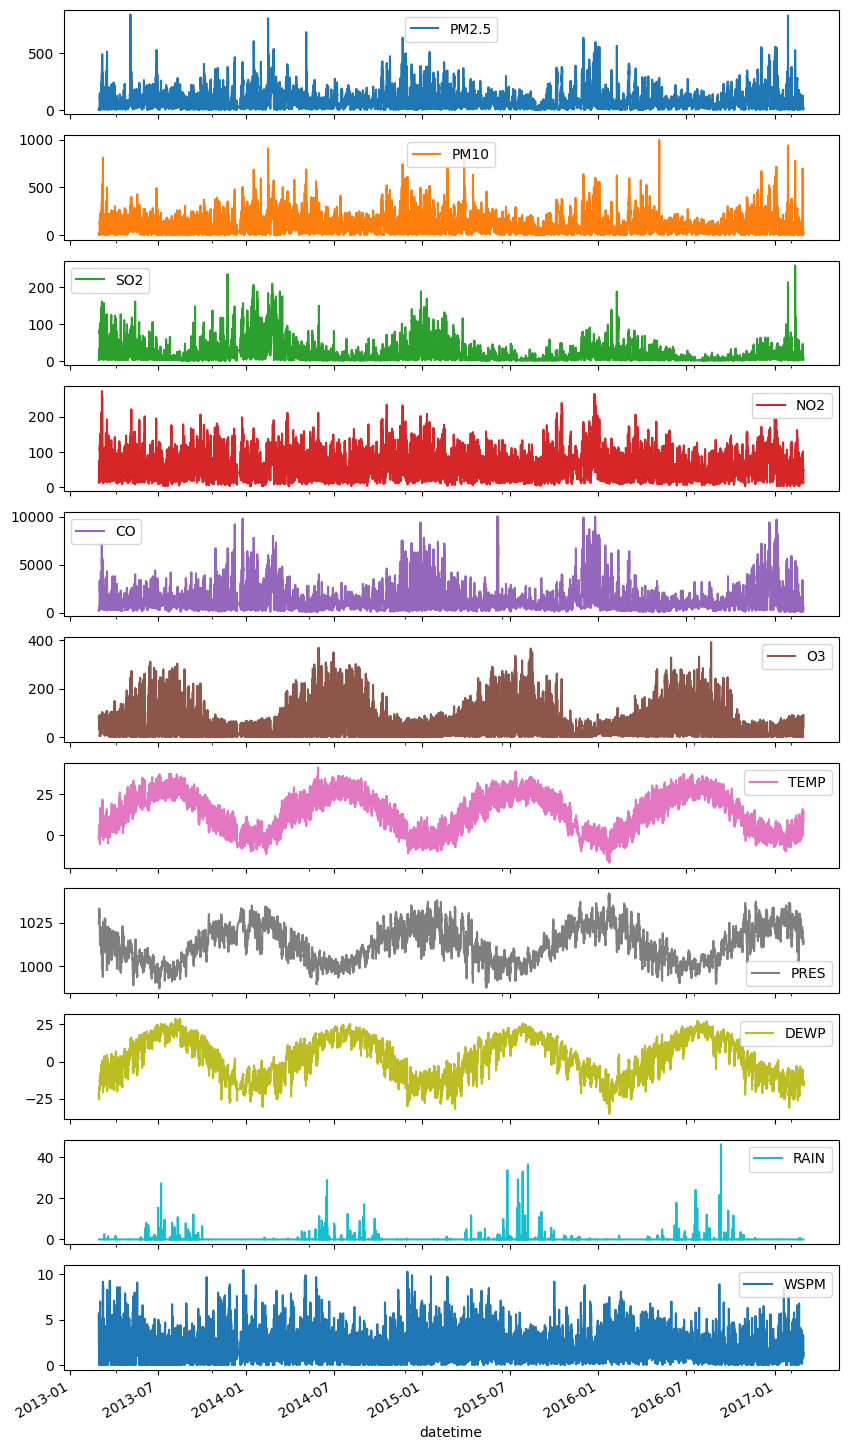

In [29]:
_ = df_daily.plot(subplots=True, figsize=(10, 20))

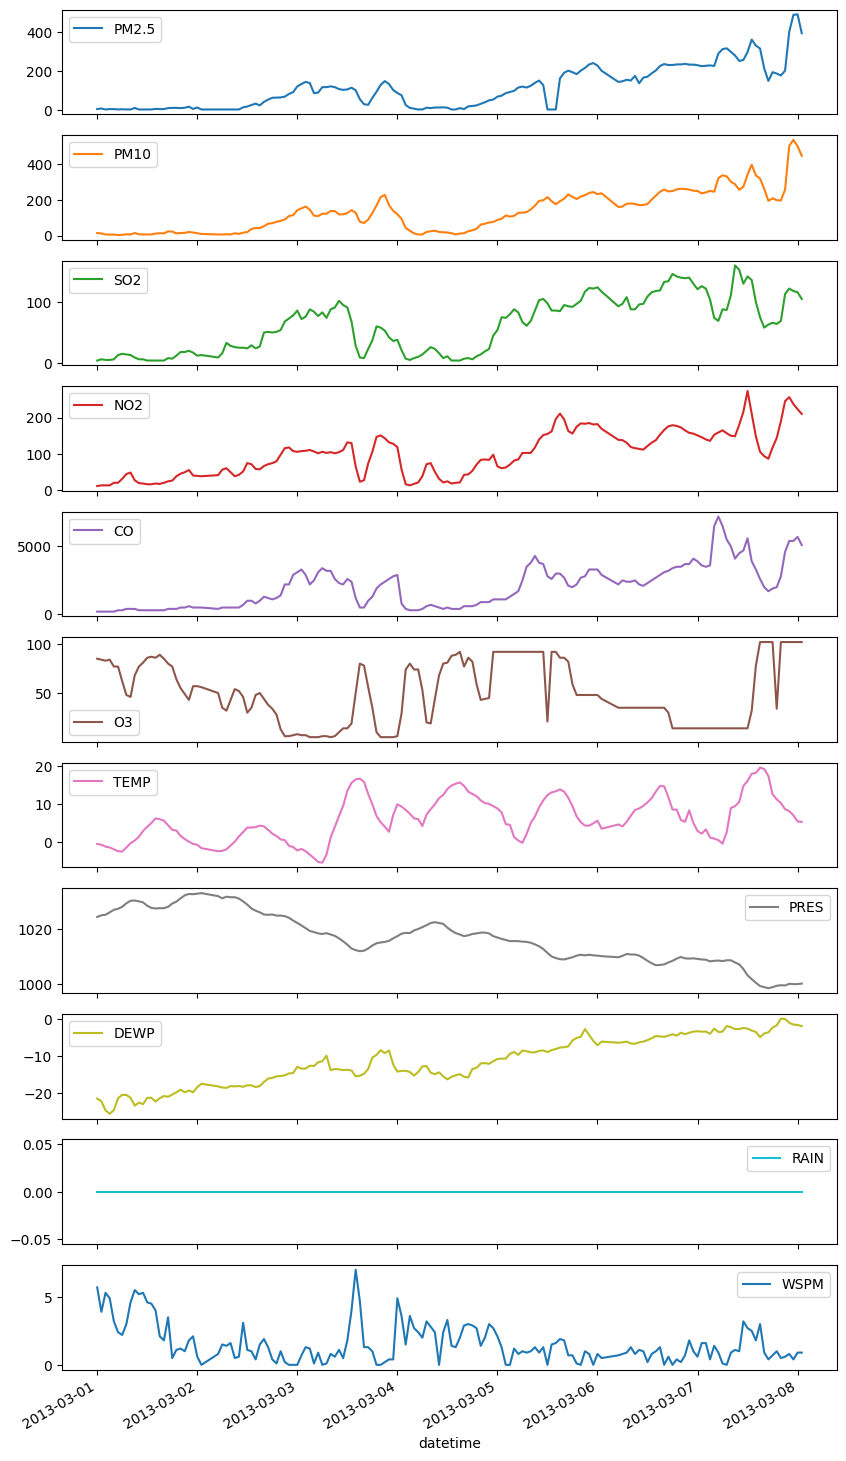

In [30]:
_ = df_daily[:164].plot(subplots=True, figsize=(10, 20))

## Density Distribution

array([<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
       <Axes: ylabel='Density'>], dtype=object)

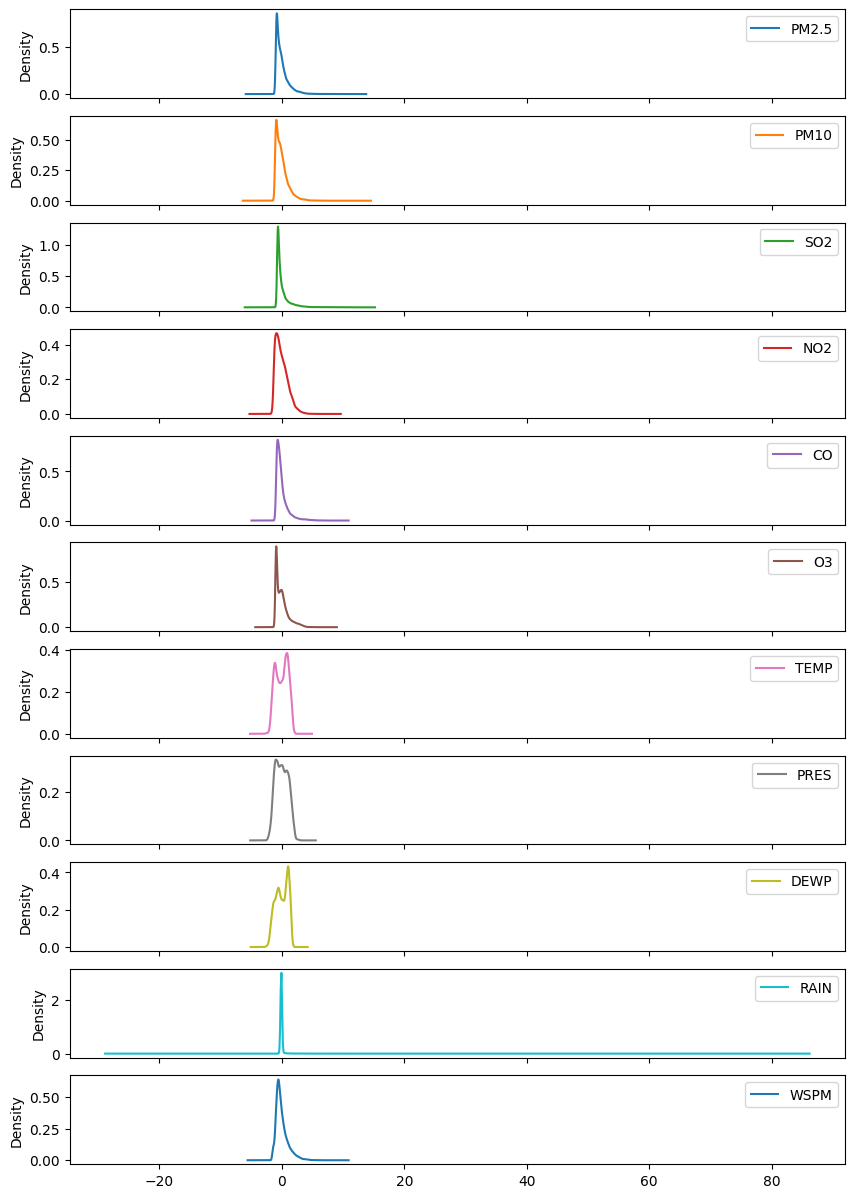

In [31]:
scaler = StandardScaler()
df_daily_scaled  = pd.DataFrame(scaler.fit_transform(df_daily), columns=df_daily.columns.to_list())
df_daily_scaled.plot.kde(subplots=True, figsize=(10, 15))

array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>], dtype=object)

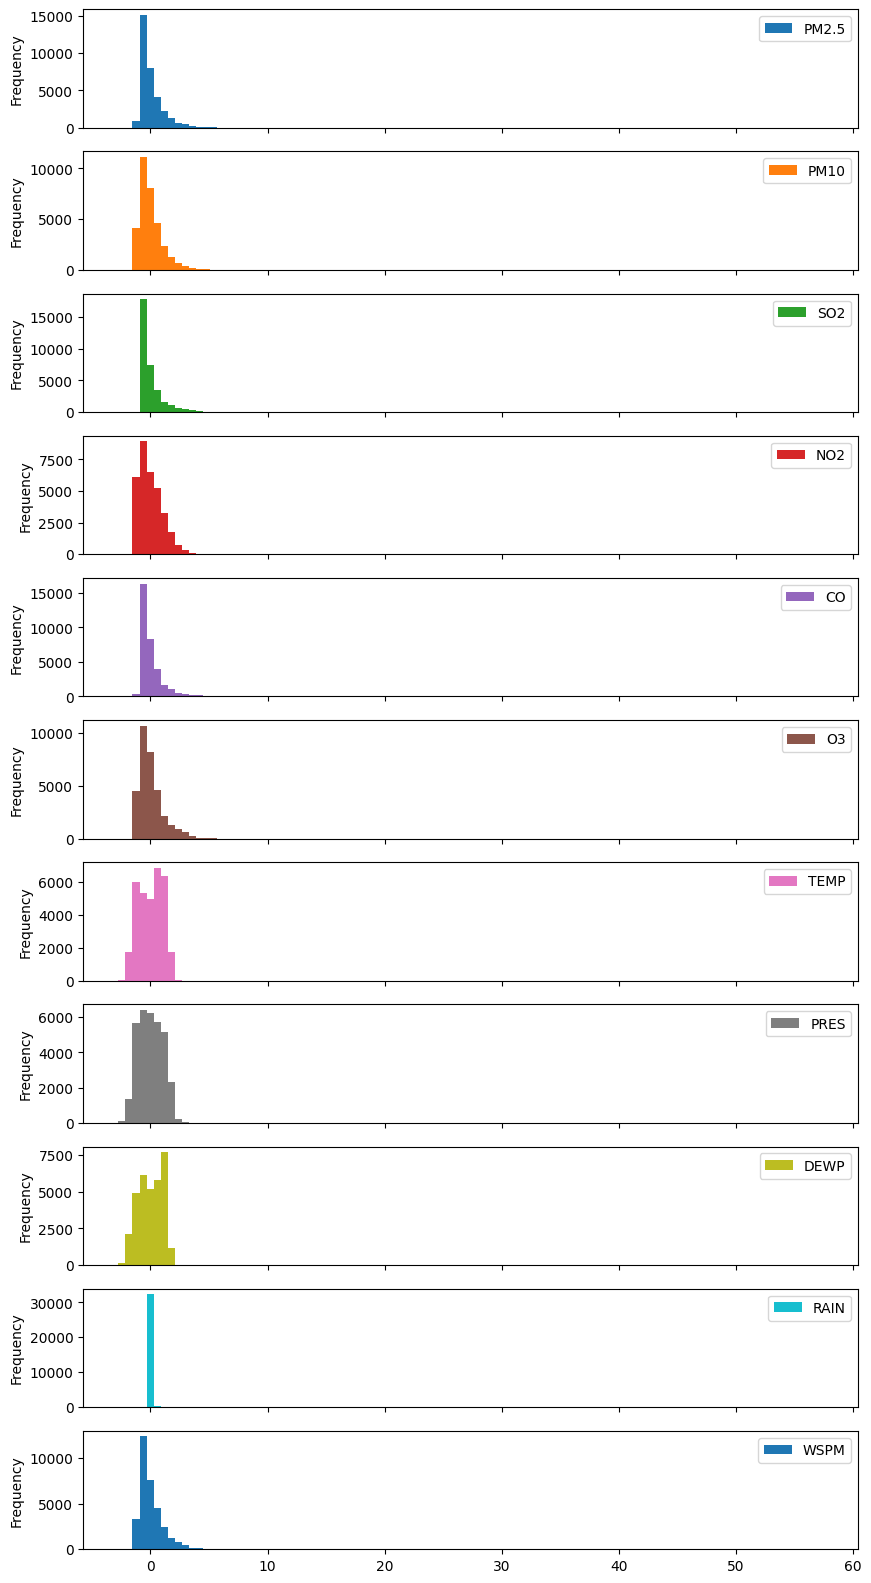

In [32]:
df_daily_scaled.plot.hist(subplots=True, figsize=(10, 20), bins=100)

array([[<Axes: xlabel='PM2.5', ylabel='PM2.5'>,
        <Axes: xlabel='PM10', ylabel='PM2.5'>,
        <Axes: xlabel='SO2', ylabel='PM2.5'>,
        <Axes: xlabel='NO2', ylabel='PM2.5'>,
        <Axes: xlabel='CO', ylabel='PM2.5'>,
        <Axes: xlabel='O3', ylabel='PM2.5'>,
        <Axes: xlabel='TEMP', ylabel='PM2.5'>,
        <Axes: xlabel='PRES', ylabel='PM2.5'>,
        <Axes: xlabel='DEWP', ylabel='PM2.5'>,
        <Axes: xlabel='RAIN', ylabel='PM2.5'>,
        <Axes: xlabel='WSPM', ylabel='PM2.5'>],
       [<Axes: xlabel='PM2.5', ylabel='PM10'>,
        <Axes: xlabel='PM10', ylabel='PM10'>,
        <Axes: xlabel='SO2', ylabel='PM10'>,
        <Axes: xlabel='NO2', ylabel='PM10'>,
        <Axes: xlabel='CO', ylabel='PM10'>,
        <Axes: xlabel='O3', ylabel='PM10'>,
        <Axes: xlabel='TEMP', ylabel='PM10'>,
        <Axes: xlabel='PRES', ylabel='PM10'>,
        <Axes: xlabel='DEWP', ylabel='PM10'>,
        <Axes: xlabel='RAIN', ylabel='PM10'>,
        <Axes: xlabel='WSPM', yl

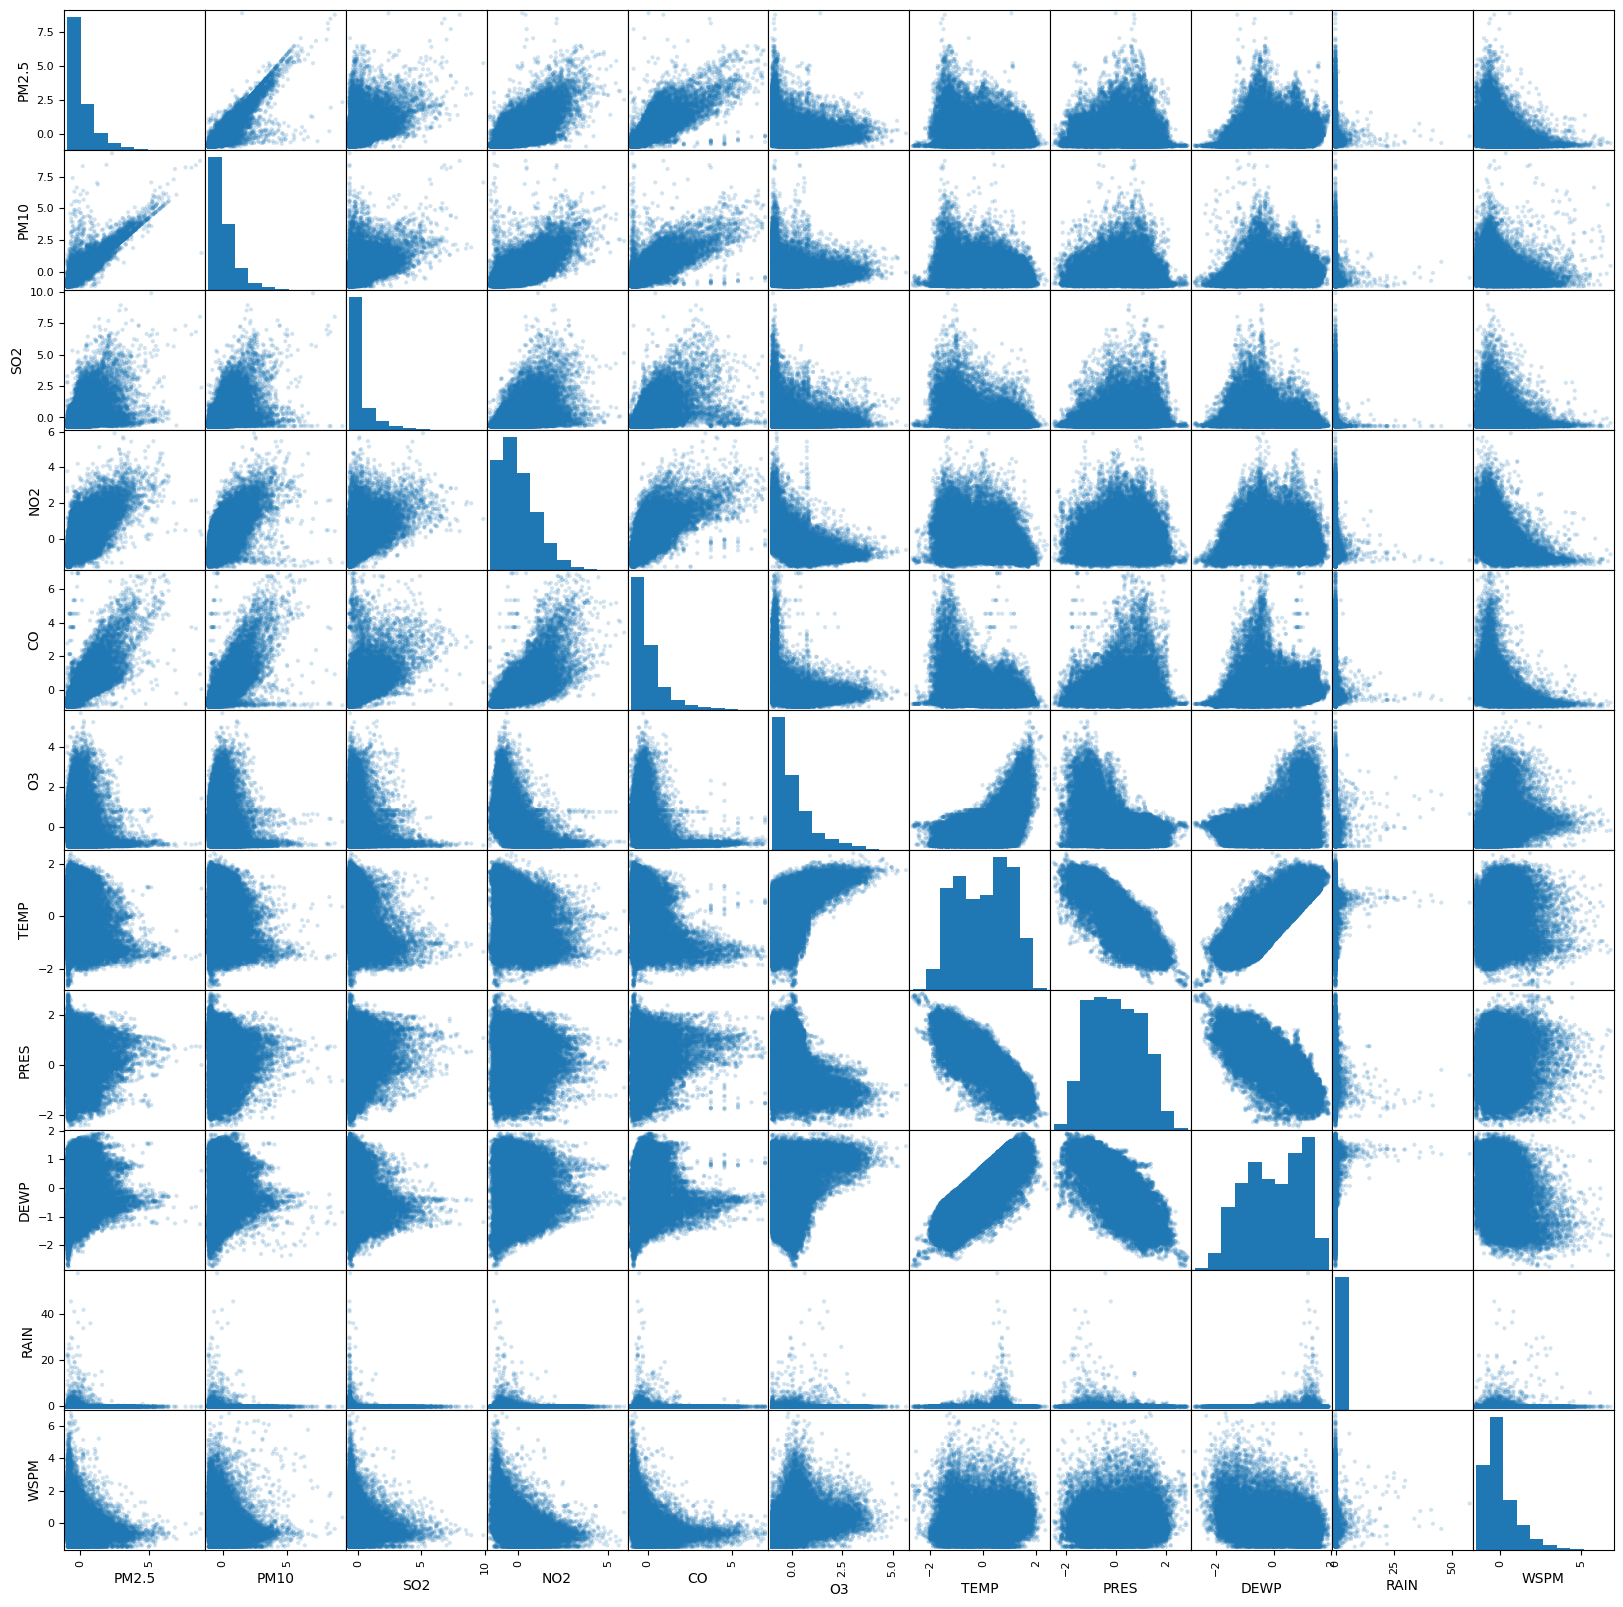

In [33]:
pd.plotting.scatter_matrix(df_daily_scaled, alpha=0.2, figsize=(20, 20))

## Feature Correlation

### Pearson Correlation

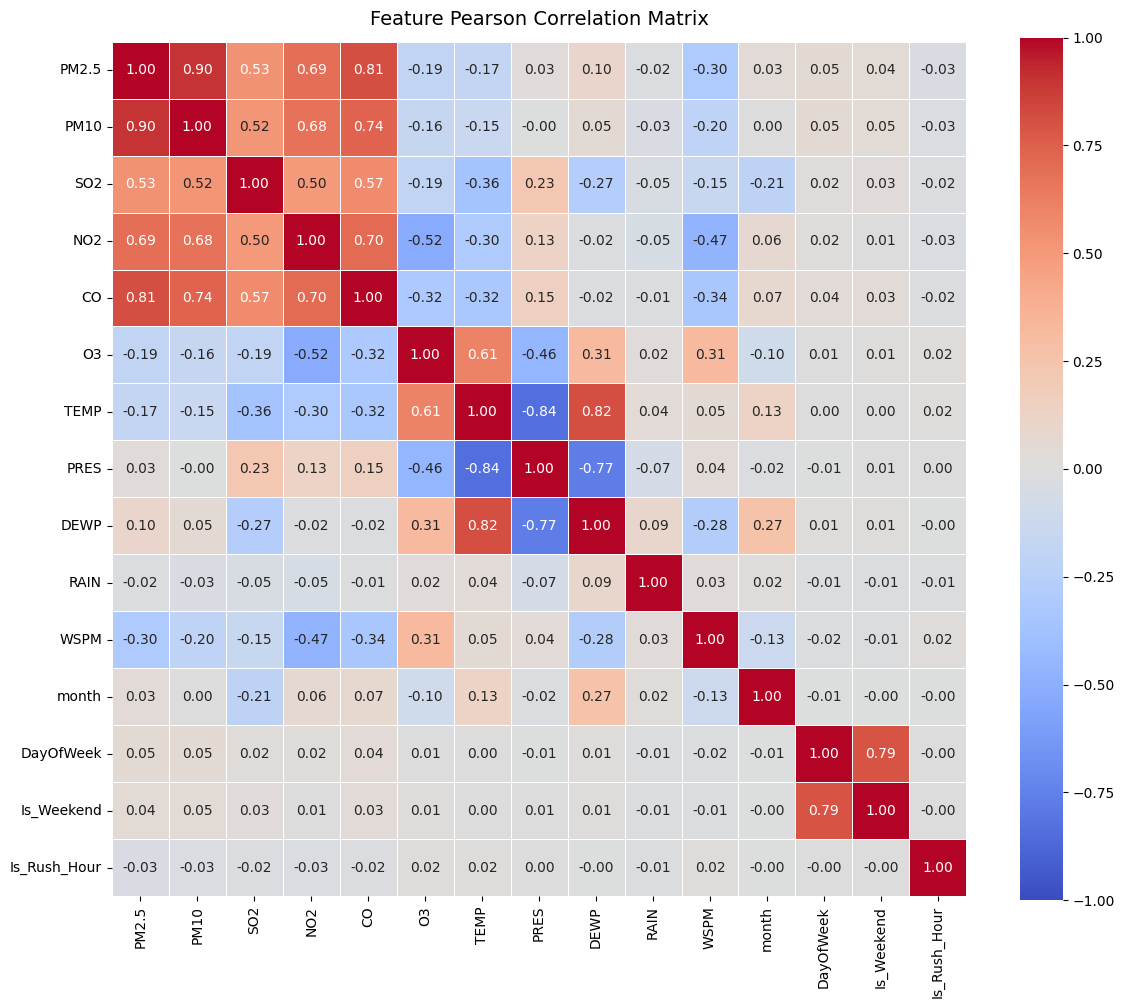

In [34]:
numeric_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'month',
    'DayOfWeek', 'Is_Weekend', 'Is_Rush_Hour'
]

corr_matrix = df[numeric_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Pearson Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

### Spearman Correlation

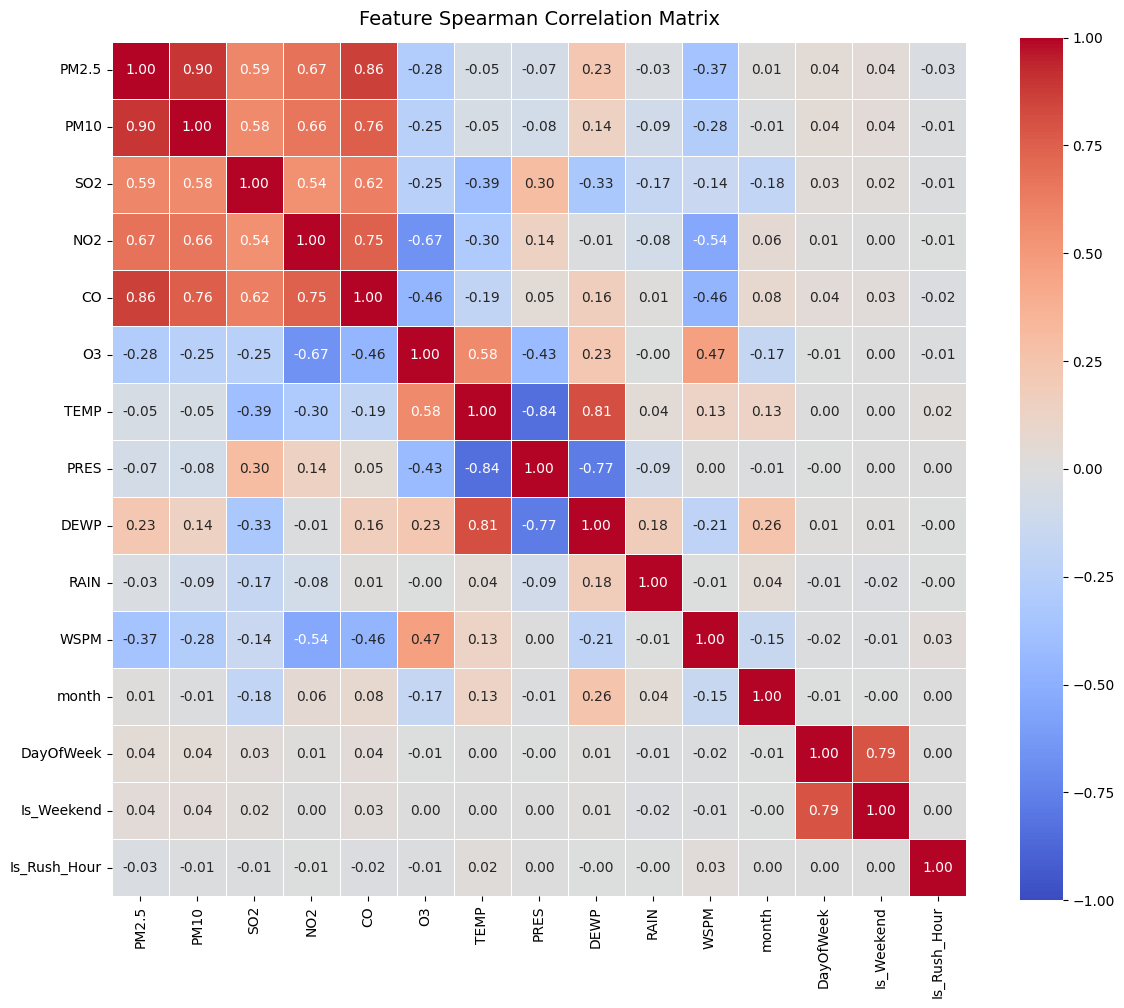

In [35]:
corr_matrix = df[numeric_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Spearman Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## Time Series Decomposition


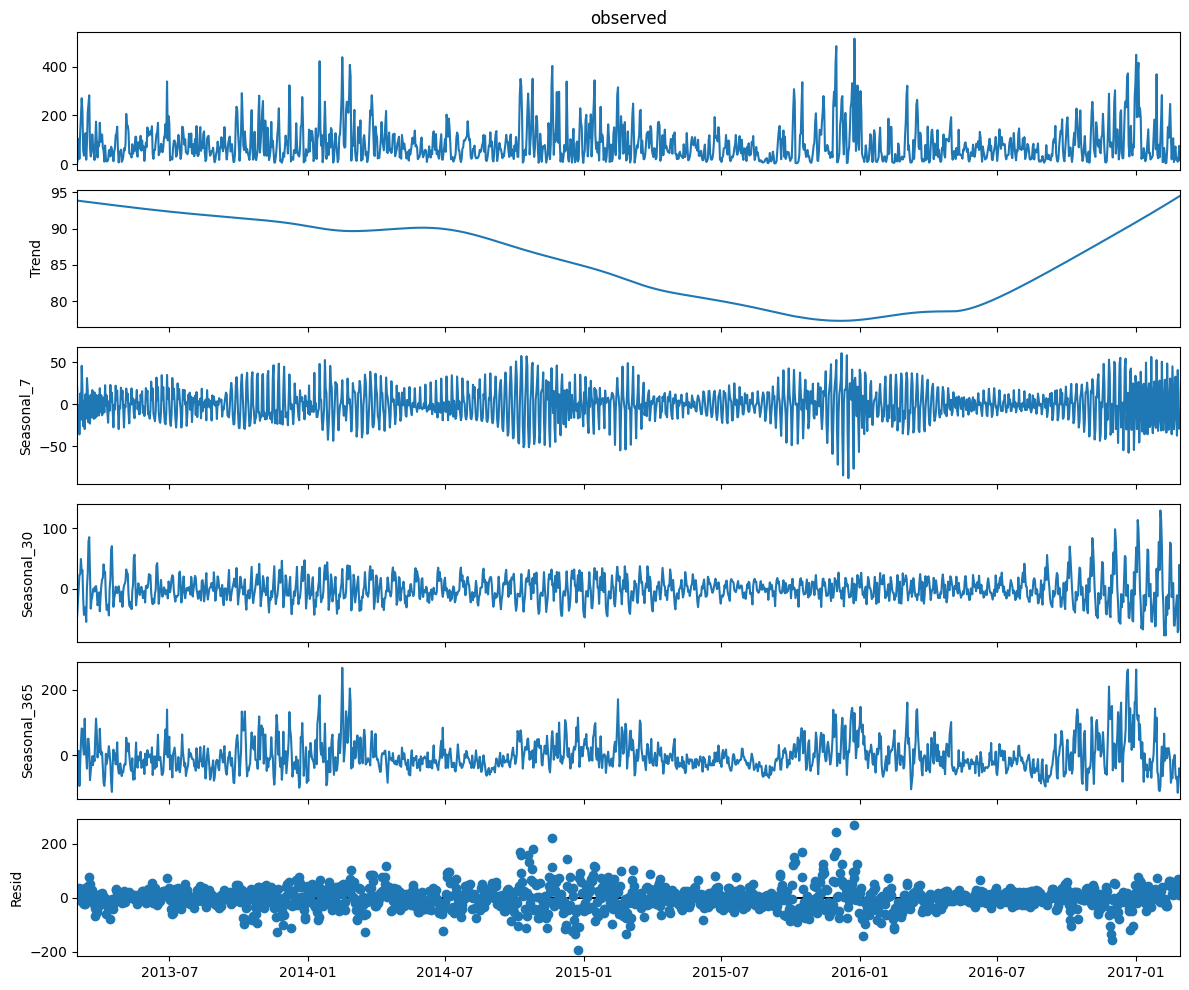

In [36]:
df_single_station = df.copy()
df_single_station.set_index("datetime", inplace=True)
df_daily = df_single_station['PM2.5'].resample('D').mean().dropna()

# Decompose with both monthly (30-day) and yearly (365-day) seasonal components
decomposition = MSTL(df_daily, periods=(7, 30, 365)).fit()

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

# Data Preprocessing

## Splitting the Data for Training, Test, Validation

the dataset was divided into a training set, test set, and validation set at a ratio of 6:2:2. source: https://www.mdpi.com/2071-1050/14/4/2068

The prediction time units used the multiple air-pollution factor values of the first 8, 16, and 24 h periods to predict the model’s input data. The output results were the PM2.5 concentration data for the next 8 h of the predicted period. source: https://www.mdpi.com/2071-1050/14/4/2068

https://deeplearningwithpython.io/chapters/chapter13_timeseries-forecasting/
https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter13_timeseries-forecasting.ipynb

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          35064 non-null  int64         
 1   month         35064 non-null  int64         
 2   day           35064 non-null  int64         
 3   hour          35064 non-null  int64         
 4   PM2.5         34436 non-null  float64       
 5   PM10          34624 non-null  float64       
 6   SO2           34618 non-null  float64       
 7   NO2           34372 non-null  float64       
 8   CO            33858 non-null  float64       
 9   O3            34558 non-null  float64       
 10  TEMP          35044 non-null  float64       
 11  PRES          35044 non-null  float64       
 12  DEWP          35044 non-null  float64       
 13  RAIN          35044 non-null  float64       
 14  wd            34986 non-null  category      
 15  WSPM          35050 non-null  float6

In [38]:
samples = df.shape[0]

In [39]:
df.select_dtypes(include=np.number).columns

Index(['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO',
       'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'DayOfWeek', 'Is_Weekend',
       'Is_Rush_Hour'],
      dtype='object')

In [40]:
df.drop(datetime_columns + ['station', 'wd'], axis = 1)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,DayOfWeek,Is_Weekend,Is_Rush_Hour
0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,5.7,4,0,0
1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,3.9,4,0,0
2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,5.3,4,0,0
3,5.0,5.0,5.0,14.0,200.0,84.0,-1.4,1026.2,-25.5,0.0,4.9,4,0,0
4,5.0,5.0,6.0,21.0,200.0,77.0,-1.9,1027.1,-24.5,0.0,3.2,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,14.0,21.0,3.0,27.0,400.0,72.0,12.5,1013.5,-16.2,0.0,2.4,1,0,1
35060,18.0,27.0,3.0,37.0,400.0,59.0,11.6,1013.6,-15.1,0.0,0.9,1,0,0
35061,15.0,39.0,5.0,50.0,600.0,41.0,10.8,1014.2,-13.3,0.0,1.1,1,0,0
35062,11.0,35.0,6.0,49.0,500.0,41.0,10.5,1014.4,-12.9,0.0,1.2,1,0,0


In [41]:
num_train_samples = int(0.5 * samples)
num_val_samples = int(0.25 * samples)
num_test_samples = samples - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 17532
num_val_samples: 8766
num_test_samples: 8766


In [42]:
train_df = df[:num_train_samples]

In [43]:

val_df = df[num_train_samples:num_train_samples + num_val_samples]
test_df = df[num_train_samples + num_val_samples:]

## Impute Missing Values

When imputing values for validation and testing dataset, do you treat them seperately from the training dataset or use the training dataset to impute and scale values in the validation and testing dataset?

         KNN MAE  Linear MAE
Gap (h)                     
2         24.800       7.167
6          8.100       7.167
24        22.292      29.632
50        26.425      11.961


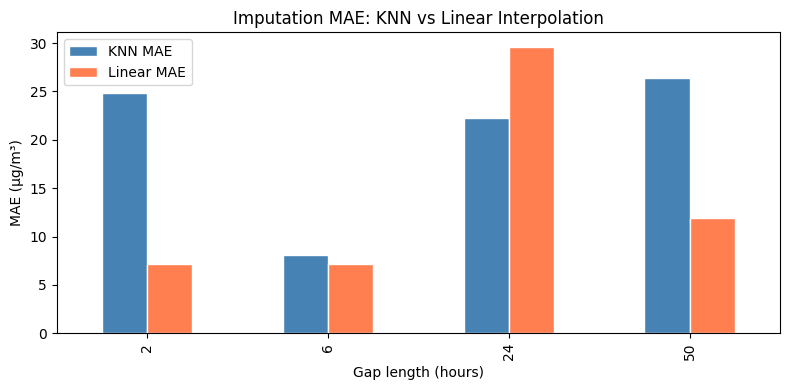

In [44]:
def impute_knn(df, k=5):
    num = df.select_dtypes(include=np.number).columns
    out = df.copy()
    out[num] = KNNImputer(n_neighbors=k).fit_transform(df[num])
    return out

def impute_linear(df):
    num = df.select_dtypes(include=np.number).columns
    out = df.copy()
    out[num] = out[num].interpolate(method='linear', limit_direction='both')
    return out

def benchmark_imputation(df, col='PM2.5', gap_list=(2, 6, 24, 50), seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for g in gap_list:
        s = rng.integers(100, len(df)-g-100)
        true_vals = df[col].iloc[s:s+g].copy()
        df_gap = df.copy()
        df_gap[col].iloc[s:s+g] = np.nan
        knn_err    = mean_absolute_error(true_vals, impute_knn(df_gap)[col].iloc[s:s+g])
        linear_err = mean_absolute_error(true_vals, impute_linear(df_gap)[col].iloc[s:s+g])
        rows.append({'Gap (h)': g, 'KNN MAE': knn_err, 'Linear MAE': linear_err})
    return pd.DataFrame(rows).set_index('Gap (h)')

bench = benchmark_imputation(train_df[CHEM_COLUMNS].dropna())
print(bench.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
bench.plot.bar(ax=ax, color=['steelblue','coral'], edgecolor='white')
ax.set_title('Imputation MAE: KNN vs Linear Interpolation')
ax.set_xlabel('Gap length (hours)'); ax.set_ylabel('MAE (µg/m³)')
plt.tight_layout(); plt.show()



In [45]:
df_imputed = train_df
df_imputed[CHEM_COLUMNS] = impute_knn(train_df[CHEM_COLUMNS])
print(f"\nMissing after KNN imputation: {df_imputed.isnull().sum().sum()}")



Missing after KNN imputation: 2


In [46]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17532 entries, 0 to 17531
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          17532 non-null  int64         
 1   month         17532 non-null  int64         
 2   day           17532 non-null  int64         
 3   hour          17532 non-null  int64         
 4   PM2.5         17532 non-null  float64       
 5   PM10          17532 non-null  float64       
 6   SO2           17532 non-null  float64       
 7   NO2           17532 non-null  float64       
 8   CO            17532 non-null  float64       
 9   O3            17532 non-null  float64       
 10  TEMP          17532 non-null  float64       
 11  PRES          17532 non-null  float64       
 12  DEWP          17532 non-null  float64       
 13  RAIN          17532 non-null  float64       
 14  wd            17530 non-null  category      
 15  WSPM          17532 non-null  float6

## Extreme Values

The processing of extreme values is also crucial. For example, when collecting data from sensors, some natural disasters and human factors might cause errors in the data sensors’ collection. Suppose these extreme values are put into the neural network for training together with the dataset. In that case, it will render the machine learning process with the wrong features, thus resulting in poor prediction performance. Therefore, to avoid the adverse effects of extreme values on machine learning training, the extreme values of the dataset were **deleted by observing each data in the dataset and setting the maximum and minimum values.** If the value in the dataset exceeds the setting value, the record will be flagged.

Winsorizing- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mstats.winsorize.html

Source: https://www.mdpi.com/2071-1050/14/4/2068

Flagged 12619 extreme values; re-imputing...


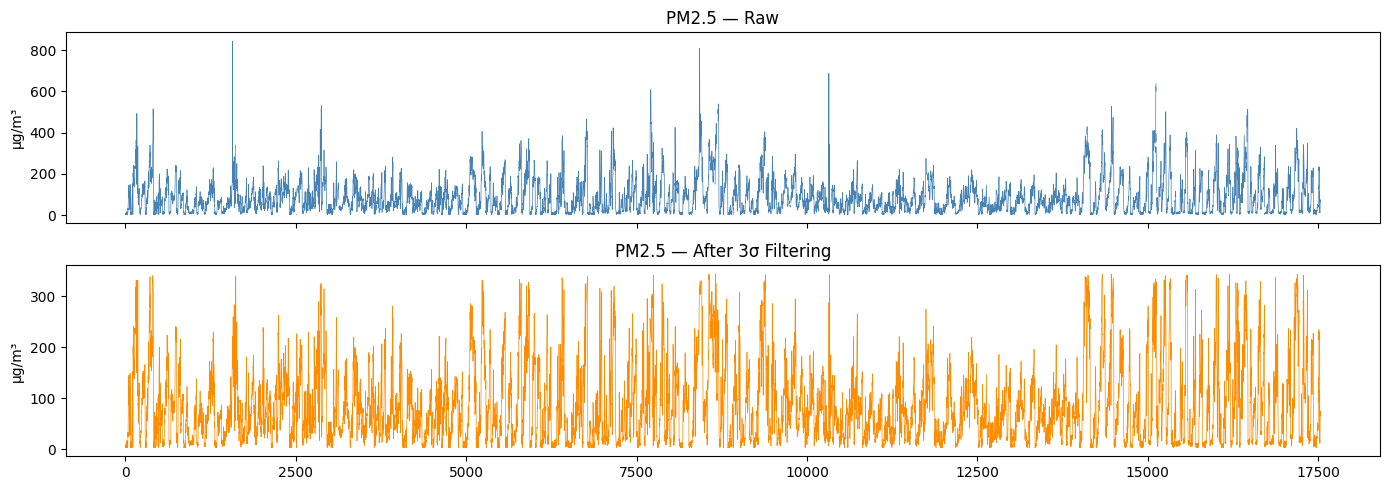

In [47]:
def remove_3sigma(df, lower=0):
    num = df.select_dtypes(include=np.number).columns
    out = df.copy(); n = 0
    for col in num:
        mu, s = out[col].mean(), out[col].std()
        hi, lo = mu + 3*s, max(mu - 3*s, lower)
        bad = (out[col] < lo) | (out[col] > hi)
        out.loc[bad, col] = np.nan; n += bad.sum()
    print(f"Flagged {n} extreme values; re-imputing...")
    return impute_linear(out)

NUM_COLS = df_imputed.select_dtypes(include=np.number).columns.tolist()
df_clean = remove_3sigma(df_imputed)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
df['PM2.5'][:num_train_samples].plot(ax=axes[0], lw=0.5, color='steelblue', title='PM2.5 — Raw')
df_clean['PM2.5'].plot(ax=axes[1], lw=0.5, color='darkorange', title='PM2.5 — After 3σ Filtering')
for ax in axes: ax.set_ylabel('µg/m³')
plt.tight_layout(); plt.show()



In [48]:
df_imputed[CHEM_COLUMNS].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PM2.5,17532.0,89.345063,85.194716,3.0000,26.0000,66.0,125.0,844.0
PM10,17532.0,116.851089,94.871887,2.0000,45.0000,97.0,161.0,907.0
SO2,17532.0,25.132547,29.470386,0.5712,5.0000,13.0,33.0,234.0
NO2,17532.0,61.615192,36.614486,2.0000,32.0000,56.0,84.0,273.0
CO,17532.0,1359.366689,1150.081743,100.0000,600.0000,1000.0,1800.0,9800.0
O3,17532.0,55.758532,58.001934,0.2142,7.9254,41.0,81.0,367.0
TEMP,17532.0,13.618056,11.318560,-11.5000,3.0000,14.4,23.2,41.1
PRES,17532.0,1012.145435,9.989836,987.1000,1003.8000,1012.0,1020.0,1038.0
DEWP,17532.0,2.323832,14.012971,-31.1000,-9.4000,2.4,15.4,28.8
RAIN,17532.0,0.051882,0.600163,0.0000,0.0000,0.0,0.0,29.0


In [49]:
df_clean[CHEM_COLUMNS].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PM2.5,17532.0,86.907126,77.003696,3.0000,26.000000,66.0,124.000000,344.0000
PM10,17532.0,114.342454,86.562811,2.0000,45.000000,97.0,160.083333,401.0000
SO2,17532.0,24.322771,26.649354,0.5712,5.000000,13.0,33.000000,113.0000
NO2,17532.0,61.301901,35.669225,2.0000,32.000000,56.0,84.000000,171.0149
CO,17532.0,1318.388273,1009.339912,100.0000,600.000000,1000.0,1800.000000,4800.0000
O3,17532.0,54.832291,55.064092,0.2142,7.925400,41.0,81.000000,229.0000
TEMP,17532.0,14.160825,10.530052,0.0000,3.100000,14.4,23.200000,41.1000
PRES,17532.0,1012.145435,9.989836,987.1000,1003.800000,1012.0,1020.000000,1038.0000
DEWP,17532.0,7.584366,8.227809,0.0000,0.290921,2.9,15.400000,28.8000
RAIN,17532.0,0.018264,0.131553,0.0000,0.000000,0.0,0.000000,1.8000


## Using Winsorizing to Replace Outliers

In statistics, the 68–95–99.7 rule, also known as the empirical rule or 68–95–99.7 rule for a normal distribution[1] and sometimes abbreviated 3sr or 3 σ, is a shorthand used to remember the percentage of values that lie within an interval estimate in a normal distribution: approximately 68%, 95%, and 99.7% of the values lie within one, two, and three standard deviations of the mean, respectively.

https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule

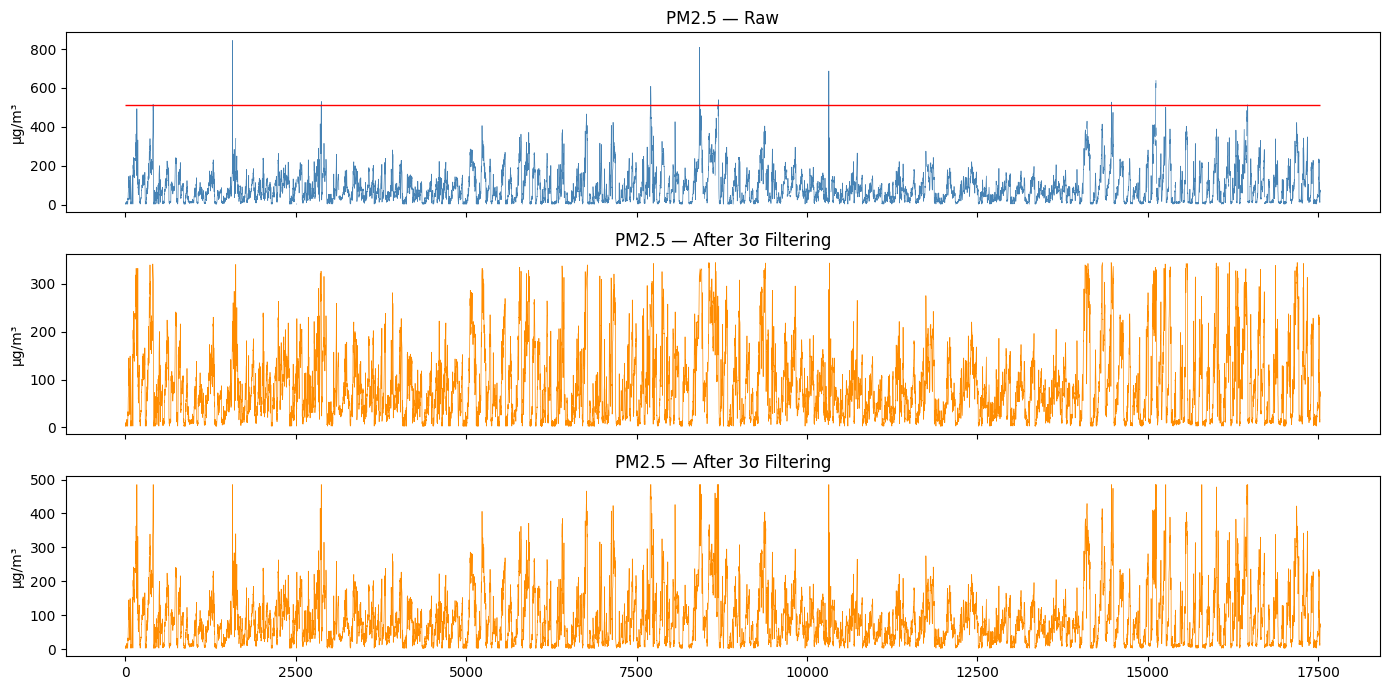

In [50]:
from scipy.stats.mstats import winsorize

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
df['PM2.5'][:num_train_samples].plot(ax=axes[0], lw=0.5, color='steelblue', title='PM2.5 — Raw')

df_winsorized = df_imputed.copy()
df_winsorized[CHEM_COLUMNS] = df_winsorized[CHEM_COLUMNS].apply(lambda x: winsorize(x ,limits=[0.0, 0.003]))

df_clean['PM2.5'].plot(ax=axes[1], lw=0.5, color='darkorange', title='PM2.5 — After 3σ Filtering')
df_winsorized['PM2.5'].plot(ax=axes[2], lw=0.5, color='darkorange', title='PM2.5 — After 3σ Filtering')

for ax in axes: ax.set_ylabel('µg/m³')
axes[0].hlines(y=df['PM2.5'].quantile(0.997), xmin=0, xmax=num_train_samples, linewidth=1, color='r')
plt.tight_layout(); plt.show()

In [53]:
df_winsorized[CHEM_COLUMNS].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PM2.5,17532.0,89.140967,84.044735,3.0000,26.0000,66.0,125.0,485.0
PM10,17532.0,116.558082,93.309853,2.0000,45.0000,97.0,161.0,530.0
SO2,17532.0,25.081954,29.202623,0.5712,5.0000,13.0,33.0,164.0
NO2,17532.0,61.560036,36.394532,2.0000,32.0000,56.0,84.0,189.0
CO,17532.0,1356.720100,1135.836913,100.0000,600.0000,1000.0,1800.0,6700.0
O3,17532.0,55.697158,57.742985,0.2142,7.9254,41.0,81.0,279.0
TEMP,17532.0,13.615387,11.313045,-11.5000,3.0000,14.4,23.2,35.7
PRES,17532.0,1012.142891,9.983978,987.1000,1003.8000,1012.0,1020.0,1034.0
DEWP,17532.0,2.320084,14.006323,-31.1000,-9.4000,2.4,15.4,26.3
RAIN,17532.0,0.038666,0.325374,0.0000,0.0000,0.0,0.0,4.5


In [54]:
# df_imputed[CHEM_COLUMNS] = df_winsorized

## One-Hot Encoding — Wind Direction

In [ ]:
# df_encoded = pd .get_dummies(df, columns=['station', 'wd'], drop_first=True)
# df_encoded['month_sin'] = np.sin(df_encoded['month'] / 12 * 2 * np.pi)
# df_encoded['month_cos'] = np.cos(df_encoded['month'] / 12 * 2 * np.pi)
# df_encoded['weekday_sin'] = np.sin(df_encoded['DayOfWeek'] / 7 * 2 * np.pi)
# df_encoded['weekday_cos'] = np.cos(df_encoded['DayOfWeek'] / 7 * 2 * np.pi)
# df_encoded['hour_sin'] = np.sin(df_encoded['hour'] / 24 * 2 * np.pi)
# df_encoded['hour_cos'] = np.cos(df_encoded['hour'] / 24 * 2 * np.pi)

In [55]:
import re

new = cyclicTransformer.fit_transform(df_winsorized).rename(columns=lambda x: re.sub('remainder__','',x), inplace=False)

new.rename(columns=lambda x: re.sub('categorical__','',x), inplace=True)

In [57]:
new.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
wd_E,17532.0,0.107061,0.0,0.0,0.0,0.0,1.0,0.3092
wd_ENE,17532.0,0.108544,0.0,0.0,0.0,0.0,1.0,0.311076
wd_ESE,17532.0,0.086299,0.0,0.0,0.0,0.0,1.0,0.280814
wd_N,17532.0,0.062457,0.0,0.0,0.0,0.0,1.0,0.241991
wd_NE,17532.0,0.079284,0.0,0.0,0.0,0.0,1.0,0.270189
wd_NNE,17532.0,0.055841,0.0,0.0,0.0,0.0,1.0,0.22962
wd_NNW,17532.0,0.049167,0.0,0.0,0.0,0.0,1.0,0.216223
wd_NW,17532.0,0.06394,0.0,0.0,0.0,0.0,1.0,0.244653
wd_S,17532.0,0.047171,0.0,0.0,0.0,0.0,1.0,0.21201
wd_SE,17532.0,0.054472,0.0,0.0,0.0,0.0,1.0,0.226953


In [58]:
new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17532 entries, 0 to 17531
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   wd_E                    17532 non-null  float64       
 1   wd_ENE                  17532 non-null  float64       
 2   wd_ESE                  17532 non-null  float64       
 3   wd_N                    17532 non-null  float64       
 4   wd_NE                   17532 non-null  float64       
 5   wd_NNE                  17532 non-null  float64       
 6   wd_NNW                  17532 non-null  float64       
 7   wd_NW                   17532 non-null  float64       
 8   wd_S                    17532 non-null  float64       
 9   wd_SE                   17532 non-null  float64       
 10  wd_SSE                  17532 non-null  float64       
 11  wd_SSW                  17532 non-null  float64       
 12  wd_SW                   17532 non-null  float6

In [59]:
new = new.drop(['day', 'year', "datetime"], axis = 1)

## Normalisation

In [ ]:
# TARGET       = 'PM2.5'
# # FEATURE_COLS = [c for c in new.columns if c != TARGET]

# scaler_X = MinMaxScaler()
# scaler_y = MinMaxScaler()
# X_scaled = scaler_X.fit_transform(new[CHEM_COLUMNS].values)
# y_scaled = scaler_y.fit_transform(new[[TARGET]].values)

# df_norm = pd.DataFrame(
#     np.hstack([X_scaled, y_scaled]),
#     columns=FEATURE_COLS + [TARGET],
#     index=df_imputed.index)
# print("Normalised value ranges (sample cols):")
# df_norm[CHEM_COLUMNS].describe().round(3)


# Preporcessing for Validation & Testing Datasets

In [60]:
mmScaler = MinMaxScaler()
mmScaler.set_output(transform='pandas')
new[CHEM_COLUMNS] = mmScaler.fit_transform(new[CHEM_COLUMNS])

In [61]:
new.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
wd_E,17532.0,0.107061,0.309200,0.000000,0.000000,0.000000e+00,0.000000,1.000000
wd_ENE,17532.0,0.108544,0.311076,0.000000,0.000000,0.000000e+00,0.000000,1.000000
wd_ESE,17532.0,0.086299,0.280814,0.000000,0.000000,0.000000e+00,0.000000,1.000000
wd_N,17532.0,0.062457,0.241991,0.000000,0.000000,0.000000e+00,0.000000,1.000000
wd_NE,17532.0,0.079284,0.270189,0.000000,0.000000,0.000000e+00,0.000000,1.000000
wd_NNE,17532.0,0.055841,0.229620,0.000000,0.000000,0.000000e+00,0.000000,1.000000
wd_NNW,17532.0,0.049167,0.216223,0.000000,0.000000,0.000000e+00,0.000000,1.000000
wd_NW,17532.0,0.063940,0.244653,0.000000,0.000000,0.000000e+00,0.000000,1.000000
wd_S,17532.0,0.047171,0.212010,0.000000,0.000000,0.000000e+00,0.000000,1.000000
wd_SE,17532.0,0.054472,0.226953,0.000000,0.000000,0.000000e+00,0.000000,1.000000


In [63]:
val_df[CHEM_COLUMNS] = mmScaler.fit_transform(val_df[CHEM_COLUMNS])

In [64]:
val_df = cyclicTransformer.fit_transform(val_df).rename(columns=lambda x: re.sub('remainder__','',x), inplace=False)

val_df.rename(columns=lambda x: re.sub('categorical__','',x), inplace=True)

In [65]:
val_df.drop(['day', 'year', "datetime"], axis=1, inplace=True)


In [66]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8766 entries, 17532 to 26297
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   wd_E                    8766 non-null   float64
 1   wd_ENE                  8766 non-null   float64
 2   wd_ESE                  8766 non-null   float64
 3   wd_N                    8766 non-null   float64
 4   wd_NE                   8766 non-null   float64
 5   wd_NNE                  8766 non-null   float64
 6   wd_NNW                  8766 non-null   float64
 7   wd_NW                   8766 non-null   float64
 8   wd_S                    8766 non-null   float64
 9   wd_SE                   8766 non-null   float64
 10  wd_SSE                  8766 non-null   float64
 11  wd_SSW                  8766 non-null   float64
 12  wd_SW                   8766 non-null   float64
 13  wd_W                    8766 non-null   float64
 14  wd_WNW                  8766 non-nu

In [67]:
test_df[CHEM_COLUMNS] = mmScaler.fit_transform(test_df[CHEM_COLUMNS])

In [68]:
test_df = cyclicTransformer.fit_transform(test_df).rename(columns=lambda x: re.sub('remainder__','',x), inplace=False)

test_df.rename(columns=lambda x: re.sub('categorical__','',x), inplace=True)

In [69]:
test_df.drop(['day', 'year', "datetime"], axis=1, inplace=True)

In [62]:
df_clean = new

# Cross Validation: Create Sequences for Deep Learning

# Create Keras Batch Datasets

In [74]:
sampling_rate = 1 # Observations will be sampled at every data point one per hour
sequence_length = 24 * 7 #  Observations will go back seven days (168 hours).
delay = sampling_rate * (sequence_length + 24 - 1) # The target for a sequence will be the PM2.5 24 hours after the end of the sequence.
batch_size = 256

In [75]:
import keras

train_dataset = keras.utils.timeseries_dataset_from_array(
    df_clean[:-delay],
    targets=df_clean['PM2.5'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    # start_index=0,
    # end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    val_df[:-delay],
    targets=val_df['PM2.5'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    # start_index=0,
    # end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    test_df[:-delay],
    targets=test_df['PM2.5'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    # batch_size=batch_size,
    # start_index=num_train_samples + num_val_samples,
)

### Debugging NaN Loss
Let's check if there are any remaining NaN values in the validation and test dataframes that are being passed into the Keras datasets.

### Reusable Preprocessing Pipeline

To ensure consistency and avoid the data leakage or missing value issues we encountered earlier, we will consolidate the cleaning, feature engineering, and scaling into a `ColumnTransformer` pipeline.

In [70]:
from sklearn.base import BaseEstimator, TransformerMixin

class Winsorizer(BaseEstimator, TransformerMixin):
    """Custom transformer to apply winsorization to specified columns."""
    def __init__(self, limits=[0.003, 0.003]):
        self.limits = limits
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_copy = X.copy()
        for col in X_copy.columns:
            X_copy[col] = winsorize(X_copy[col], limits=self.limits)
        return X_copy

# Define feature groups
cyclic_features = ['month', 'DayOfWeek', 'hour']
cat_features = ['wd']
chemical_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
weather_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# 1. Cyclic Transformer for time features
time_pipeline = ColumnTransformer([
    ("month_sin", sin_transformer(12), ["month"]),
    ("month_cos", cos_transformer(12), ["month"]),
    ("weekday_sin", sin_transformer(7), ["DayOfWeek"]),
    ("weekday_cos", cos_transformer(7), ["DayOfWeek"]),
    ("hour_sin", sin_transformer(24), ["hour"]),
    ("hour_cos", cos_transformer(24), ["hour"]),
])

# 2. Main Preprocessing Pipeline
preprocessing_pipeline = ColumnTransformer([
    # Chemical features: Impute -> Winsorize -> Scale
    ('chem', Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('winsor', Winsorizer(limits=[0.0, 0.003])),
        ('scaler', MinMaxScaler())
    ]), chemical_cols),

    # Weather features: Impute -> Scale
    ('weather', Pipeline([
        ('imputer', KNNImputer(n_neighbors=3)),
        ('scaler', MinMaxScaler())
    ]), weather_cols),

    # Categorical: One-Hot
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),

    # Time: Cyclic encoding
    ('time_month_sin', sin_transformer(12), ['month']),
    ('time_month_cos', cos_transformer(12), ['month']),
    ('time_dow_sin', sin_transformer(7), ['DayOfWeek']),
    ('time_dow_cos', cos_transformer(7), ['DayOfWeek']),
    ('time_hour_sin', sin_transformer(24), ['hour']),
    ('time_hour_cos', cos_transformer(24), ['hour']),

    # Passthrough binary features
    ('binary', 'passthrough', ['Is_Weekend', 'Is_Rush_Hour'])
])

# Set output to pandas for easier inspection
preprocessing_pipeline.set_output(transform="pandas")

print("Preprocessing pipeline successfully defined.")

ValueError: Unable to configure output for Winsorizer(limits=[0.0, 0.003]) because `set_output` is not available.

In [72]:
print(f"NaNs in train_df: {df_clean.isnull().sum().sum()}")
print(f"NaNs in val_df:   {val_df.isnull().sum().sum()}")
print(f"NaNs in test_df:  {test_df.isnull().sum().sum()}")

# Display specific columns with NaNs in validation if any exist
if val_df.isnull().sum().sum() > 0:
    display(val_df.isnull().sum()[val_df.isnull().sum() > 0])

NaNs in train_df: 0
NaNs in val_df:   968
NaNs in test_df:  972


,0
PM2.5,247
PM10,138
SO2,140
NO2,144
CO,156
O3,143


In [76]:
# Impute missing values in validation and test sets using the KNN logic
# We use the existing CHEM_COLUMNS list to target the features needing imputation

val_df[CHEM_COLUMNS] = impute_knn(val_df[CHEM_COLUMNS])
test_df[CHEM_COLUMNS] = impute_knn(test_df[CHEM_COLUMNS])

print(f"NaNs remaining in val_df: {val_df.isnull().sum().sum()}")
print(f"NaNs remaining in test_df: {test_df.isnull().sum().sum()}")

# Re-create the Keras datasets with the cleaned data
import keras

train_dataset = keras.utils.timeseries_dataset_from_array(
    df_clean[:-delay],
    targets=df_clean['PM2.5'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    val_df[:-delay],
    targets=val_df['PM2.5'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    test_df[:-delay],
    targets=test_df['PM2.5'][delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False
)

print("Datasets successfully re-created without NaNs.")

NaNs remaining in val_df: 0
NaNs remaining in test_df: 0
Datasets successfully re-created without NaNs.


# Baseline Models

## Naive Forecast, Moving Average Forecast, Seasonal Naive Forecast

In [118]:
df_baseline = df_winsorized.copy()

In [119]:
grouped = df_baseline['PM2.5']

# 1. Naive Forecast (Shift by 1 hour, grouped by station)
df_baseline['Naive_Forecast'] = grouped.shift(1)

# 2. Moving Average Forecast (3-hour rolling average, grouped by station)
df_baseline['Moving_Avg_Forecast'] = grouped.transform(lambda x: x.rolling(window=3).mean().shift(1))

# 3. Seasonal Naive Forecast (Shift by 24 hours, grouped by station)
df_baseline['Seasonal_Naive_Forecast'] = grouped.shift(24)

df_all['Is_Hazardous'] = (df_all['PM2.5'] > 75).astype(int)
df_all['Naive_Is_Hazardous'] = (df_all['Naive_Forecast'] > 75).astype(int)
df_all['Moving_Avg_Is_Hazardous'] = (df_all['Moving_Avg_Forecast'] > 75).astype(int)
df_all['Seasonal_Naive_Is_Hazardous'] = (df_all['Seasonal_Naive_Forecast'] > 75).astype(int)

In [121]:
# 1. Isolate one station and make sure it's sorted chronologically
df_station = df_winsorized.copy() #[df['station'] == 'Aotizhongxin'].copy()
df_station = df_station.sort_values('datetime').reset_index(drop=True)

# 2. Set up lists to store the MAE for each horizon (1 to 24)
horizons = range(1, 25)
mae_naive, mae_ma, mae_seasonal = [], [], []

# 3. Loop through each hour in the future
for h in horizons:

    # The Ground Truth: Shift the PM2.5 column UP by 'h' rows to represent the future
    y_true = df_station['PM2.5'].shift(-h)

    # Baseline 1: Naive (Predict the current hour's value for the future)
    y_pred_naive = df_station['PM2.5']

    # Baseline 2: 3-Hour Moving Average (Predict the current average for the future)
    y_pred_ma = df_station['PM2.5'].rolling(window=3).mean()

    # Baseline 3: Seasonal Naive
    # To predict 'h' hours ahead, we look at what happened exactly 24 hours before that target time.
    y_pred_seasonal = df_station['PM2.5'].shift(24 - h)

    # Create a temporary dataframe to easily drop NAs created by all the shifting
    temp_df = pd.DataFrame({
        'True': y_true,
        'Naive': y_pred_naive,
        'MA': y_pred_ma,
        'Seasonal': y_pred_seasonal
    }).dropna()

    # Calculate and store the MAE for this specific horizon
    mae_naive.append(mean_absolute_error(temp_df['True'], temp_df['Naive']))
    mae_ma.append(mean_absolute_error(temp_df['True'], temp_df['MA']))
    mae_seasonal.append(mean_absolute_error(temp_df['True'], temp_df['Seasonal']))

    # (Optional: You could do the exact same thing here using mean_squared_error
    # wrapped in np.sqrt() to store RMSE!)

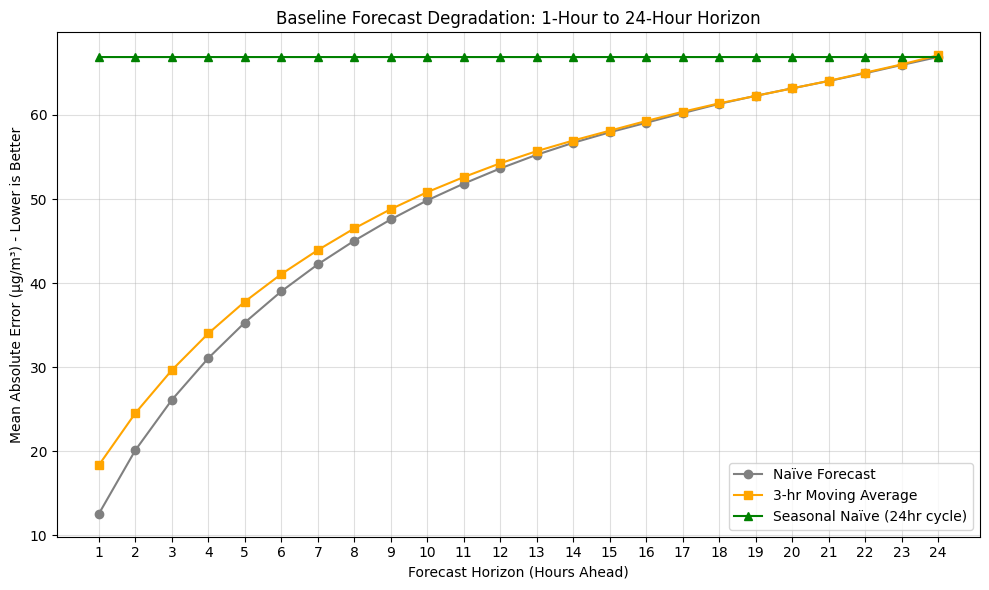

In [122]:
plt.figure(figsize=(10, 6))

# Plot the three error curves
plt.plot(horizons, mae_naive, label='Naïve Forecast', marker='o', color='gray')
plt.plot(horizons, mae_ma, label='3-hr Moving Average', marker='s', color='orange')
plt.plot(horizons, mae_seasonal, label='Seasonal Naïve (24hr cycle)', marker='^', color='green')

# Format the chart
plt.title('Baseline Forecast Degradation: 1-Hour to 24-Hour Horizon')
plt.xlabel('Forecast Horizon (Hours Ahead)')
plt.ylabel('Mean Absolute Error (µg/m³) - Lower is Better')
plt.xticks(horizons) # Force it to show 1 through 24 on the x-axis
plt.legend()
plt.grid(alpha=0.4)

plt.tight_layout()
plt.show()

## StatsForecast Models

In [ ]:
from statsforecast import StatsForecast

horizon = 24 # 24 hour period

models = [Naive(), HistoricAverage(), WindowAverage(window_size=24), SeasonalNaive(season_length=24)]

sf = StatsForecast(models=models, freq='h')
sf.fit(df_station, id_col="station", time_col='datetime', target_col="PM2.5")
preds = sf.predict(h=horizon)

In [ ]:
preds.head()

In [ ]:
plot_series(df_station, forecasts_df=preds, max_insample_length=24, id_col="station", time_col='datetime', target_col="PM2.5")

In [ ]:
categorical_columns = df.columns[df.dtypes == "category"]
print("Categorical features:", categorical_columns.tolist())

In [ ]:
columns_to_drop = [col for col in df.columns.to_list() if col not in ["PM2.5", "station", "datetime"]]

In [ ]:
test = df.drop(columns_to_drop, axis=1).groupby("station").tail(24)
train = df.drop(columns_to_drop, axis=1).drop(test.index).reset_index(drop=True)

In [ ]:
sf.fit(df=train, id_col="station", time_col='datetime', target_col="PM2.5")

preds = sf.predict(h=horizon)

eval_df = pd.merge(test, preds, 'left', ['station', 'datetime'])

In [ ]:
from utilsforecast.losses import mae
from utilsforecast.evaluation import evaluate

evaluation = evaluate(
    eval_df,
    metrics=[mae],
    id_col="station", time_col='datetime', target_col="PM2.5"
)
evaluation.head()

In [ ]:
evaluation = evaluation.drop(['station'], axis=1).groupby('metric').mean().reset_index()

In [ ]:
evaluation

In [ ]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

# Time-based Cross-Validation

In [78]:
ts_cv = TimeSeriesSplit(
    n_splits=5,
    gap=48,
    max_train_size=10000,
    test_size=1000,
)

# Prep for Training

Rescale the target variable (PM2.5) to predict a relative demand so that the mean absolute error is more easily interpreted as a fraction of the maximum demand.

Note

The fit method of the models used in this notebook all minimizes the mean squared error to estimate the conditional mean. The absolute error, however, would estimate the conditional median.

Nevertheless, when reporting performance measures on the test set in the discussion, we choose to focus on the mean absolute error instead of the (root) mean squared error because it is more intuitive to interpret. Note, however, that in this study the best models for one metric are also the best ones in terms of the other metric.

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html


# Dimensionality Reduction

In [88]:
# T-SNE Implementation
X_reduced_tsne = TSNE(n_components=3, random_state=69420).fit_transform(df_clean.values)

In [80]:
# PCA Implementation
X_reduced_pca = PCA(n_components=len(df_clean.columns.to_list()), random_state=69420).fit_transform(df_clean.values)

In [81]:
# TruncatedSVD
X_reduced_svd = TruncatedSVD(n_components=len(df_clean.columns.to_list()), algorithm='randomized', random_state=69420).fit_transform(df_clean.values)

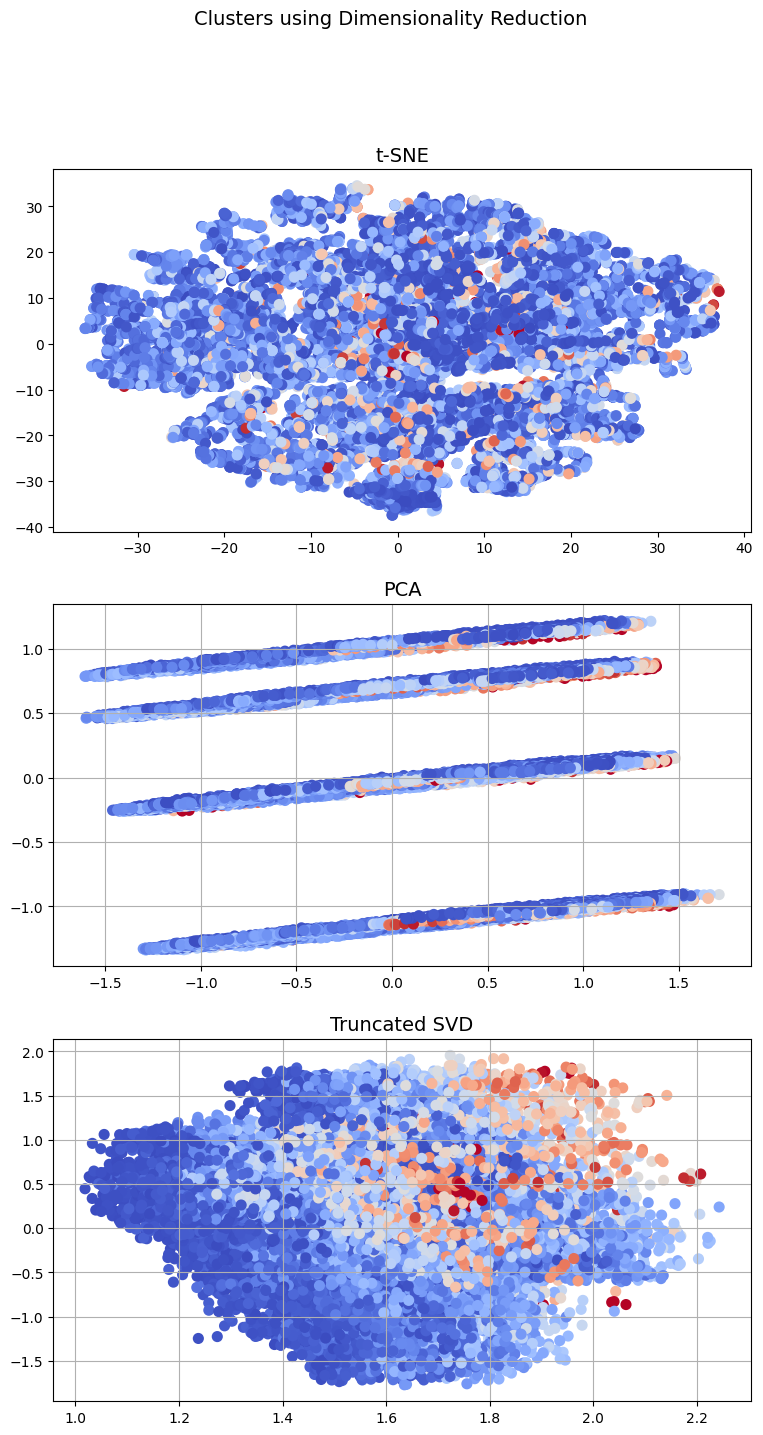

In [94]:
f, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9,16))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


# blue_patch = mpl.patches.Patch(color='#0A0AFF', label='No Ransom')
# red_patch = mpl.patches.Patch(color='#AF0000', label='Ransom')


# t-SNE scatter plot
# ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='No Ransom', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=df_clean['PM2.5'], cmap='coolwarm', label='PM2.5', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

# ax1.grid(True)

# ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
# ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=df_clean['PM2.5'], cmap='coolwarm', label='PM2.5', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

# ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
# ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=df_clean['PM2.5'], cmap='coolwarm', label='PM2.5', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

# ax3.legend(handles=[blue_patch, red_patch])

plt.show()

# Time Lag Experiment

In [95]:
from scipy.stats import pearsonr
import warnings

# ── Config ────────────────────────────────────────────────────────────────────
TARGET    = 'PM2.5'                        # correlate against raw PM2.5
LAG_RANGE = range(1, 49)                   # test lags 1h → 48h
FEATURES  = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
             'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


In [96]:
# ── 1. Compute Pearson r at each lag for each feature ─────────────────────────
# Work on a single station to keep temporal ordering clean
df_station = df_clean.copy()

results = []

for feature in FEATURES:
    for lag in LAG_RANGE:
        lagged  = df_station[feature].shift(lag)       # feature at time t-lag
        target  = df_station[TARGET]                   # PM2.5 at time t

        # Drop NaNs introduced by shift
        valid   = pd.concat([lagged, target], axis=1).dropna()

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r, p = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])

        results.append({
            'Feature': feature,
            'Lag (hours)': lag,
            'Pearson r': r,
            'p-value': p,
            'Significant': p < 0.05
        })

results_df = pd.DataFrame(results)


In [97]:
# ── 2. Find optimal lag per feature (highest |r|) ─────────────────────────────
best_lags = (
    results_df.loc[results_df.groupby('Feature')['Pearson r']
                              .apply(lambda x: x.abs().idxmax())]
    .sort_values('Pearson r', ascending=False)
    .reset_index(drop=True)
)
print("Optimal lag per feature:")
print(best_lags[['Feature', 'Lag (hours)', 'Pearson r', 'p-value']].to_string(index=False))


Optimal lag per feature:
Feature  Lag (hours)  Pearson r       p-value
  PM2.5            1   0.959087  0.000000e+00
   PM10            1   0.862821  0.000000e+00
     CO            1   0.800409  0.000000e+00
    NO2            1   0.668291  0.000000e+00
    SO2            1   0.572043  0.000000e+00
   PRES           48   0.207056 1.324370e-168
   DEWP            1   0.134608  1.118053e-71
   RAIN            3  -0.056890  4.786704e-14
   TEMP           22  -0.164158 5.101658e-106
     O3            1  -0.193293 3.579871e-147
   WSPM            3  -0.334252  0.000000e+00


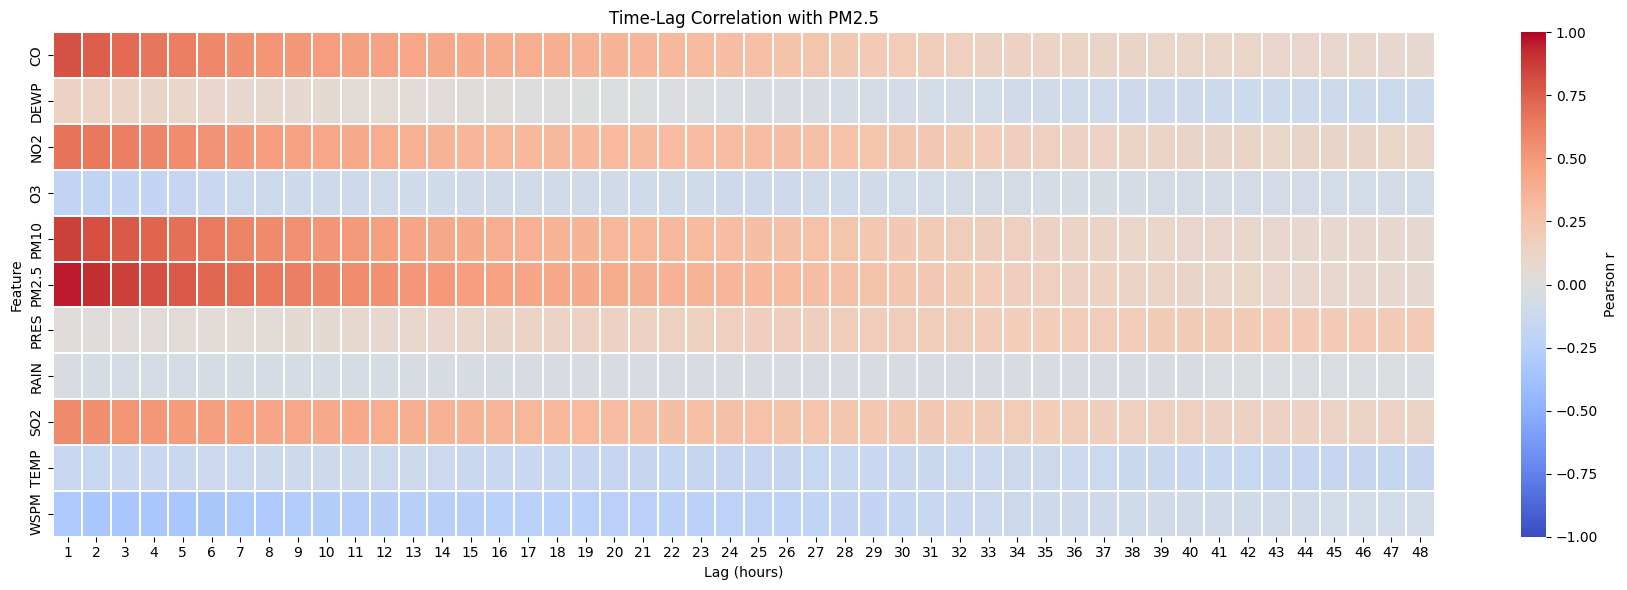

In [98]:
# ── 3. Heatmap — Pearson r across all features and lags ──────────────────────
pivot = results_df.pivot(index='Feature', columns='Lag (hours)', values='Pearson r')

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    pivot,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.2, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title(f'Time-Lag Correlation with {TARGET}')
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


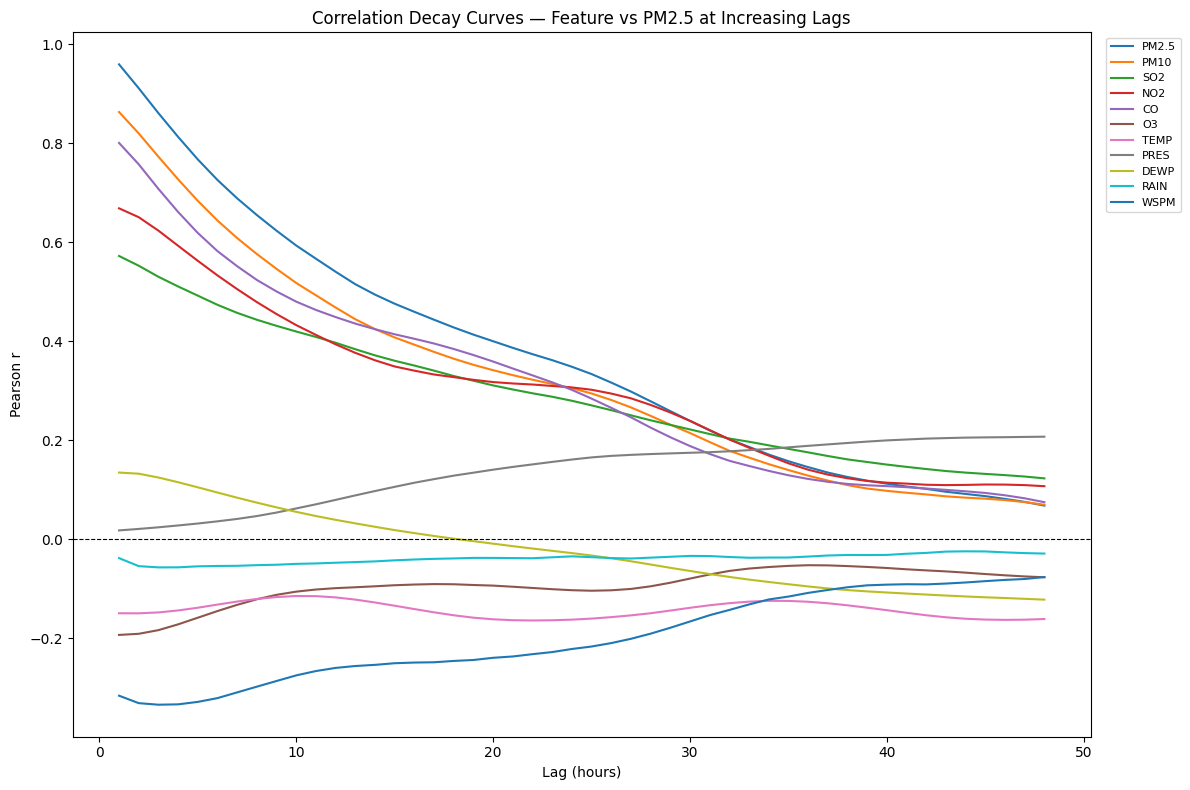

Added: PM2.5_lag1  (r=0.959)
Added: PM10_lag1  (r=0.863)
Added: CO_lag1  (r=0.800)
Added: NO2_lag1  (r=0.668)
Added: SO2_lag1  (r=0.572)
Added: PRES_lag48  (r=0.207)
Added: DEWP_lag1  (r=0.135)
Added: RAIN_lag3  (r=-0.057)
Added: TEMP_lag22  (r=-0.164)
Added: O3_lag1  (r=-0.193)
Added: WSPM_lag3  (r=-0.334)


In [99]:
# ── 4. Line plot — correlation decay curves per feature ──────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
for feature in FEATURES:
    subset = results_df[results_df['Feature'] == feature]
    ax.plot(subset['Lag (hours)'], subset['Pearson r'], label=feature, linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Pearson r')
ax.set_title(f'Correlation Decay Curves — Feature vs {TARGET} at Increasing Lags')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ── 5. (Optional) Add optimal lag features back to the model ─────────────────
for _, row in best_lags.iterrows():
    feat    = row['Feature']
    optimal = int(row['Lag (hours)'])
    col     = f"{feat}_lag{optimal}"
    df[col] = df.groupby('station')[feat].shift(optimal)
    print(f"Added: {col}  (r={row['Pearson r']:.3f})")

## Pearson Correlation

## Spearman Correlation

# Feature Engineering

In [ ]:
categorical_columns = df.columns[df.dtypes == "category"]
print("Categorical features:", categorical_columns.tolist())

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV


alphas = np.logspace(-6, 6, 25)

# cyclic_cossin_transformer = ColumnTransformer(
#     transformers=[
#         ("categorical", one_hot_encoder, categorical_columns),
#         ("month_sin", sin_transformer(12), ["month"]),
#         ("month_cos", cos_transformer(12), ["month"]),
#         ("weekday_sin", sin_transformer(7), ["DayOfWeek"]),
#         ("weekday_cos", cos_transformer(7), ["DayOfWeek"]),
#         ("hour_sin", sin_transformer(24), ["hour"]),
#         ("hour_cos", cos_transformer(24), ["hour"]),
#     ],
#     remainder=MinMaxScaler(),
# )

cyclic_cossin_linear_pipeline = make_pipeline(
    # cyclic_cossin_transformer,
    RidgeCV(alphas=alphas),
)

tempX = df_clean.copy()
tempy = df_clean['PM2.5']

sklearnEvaluate(cyclic_cossin_linear_pipeline, tempX, tempy, cv=ts_cv)

## Scale/Normalize The Data

https://www.tensorflow.org/tutorials/structured_data/time_series#normalize_the_data

In [ ]:
def plotViolin(df, train_mean, train_std):
    df_std = (df - train_mean) / train_std
    df_std = df_std.melt(var_name='Column', value_name='Normalized')
    plt.figure(figsize=(12, 6))
    ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
    _ = ax.set_xticklabels(df.keys(), rotation=90)


In [ ]:
def standardScale(x_train, x_test, y_train, y_test, df):
    train_mean = x_train.mean()
    train_std = x_train.std()

    X_train_scaled = (x_train - train_mean) / train_std
    # val_df = (val_df - train_mean) / train_std
    X_test_scaled = (x_test - train_mean) / train_std

    y_train_array = y_train.values
    y_test_array = y_test.values

    # plotViolin(df, train_mean, train_std)

    return X_train_scaled, X_test_scaled, y_train_array, y_test_array

In [ ]:
def minMaxScale(X_train, X_test, y_train, y_test, df):
    train_mean = X_train.mean()
    train_std = X_train.std()

    X_train_scaled = (X_train - train_mean) / train_std
    # val_df = (val_df - train_mean) / train_std
    X_test_scaled = (X_test - train_mean) / train_std

    y_train_array = y_train.values
    y_test_array = y_test.values

    # plotViolin(df, train_mean, train_std)

    return X_train_scaled, X_test_scaled, y_train_array, y_test_array

# Histogram-based Gradient Boosting Regression Tree

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#gradient-boosting

In [112]:
gbrt = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=42)

In [124]:
sklearnEvaluate(gbrt, df_clean.drop('PM2.5', axis = 1), df_clean['PM2.5'], cv=ts_cv, model_prop="n_iter_")

Mean model.n_iter_ = 100.0
Mean Absolute Error:     0.029 +/- 0.005
Root Mean Squared Error: 0.044 +/- 0.008


# Random Forest Regressor

In [125]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

In [127]:
sklearnEvaluate(rf_model, df_clean.drop('PM2.5', axis = 1), df_clean['PM2.5'], cv=ts_cv)

Mean Absolute Error:     0.031 +/- 0.005
Root Mean Squared Error: 0.047 +/- 0.008


# Normalization using Vectorization

# Deep Learning

# RNN, LSTM, CNN

In [101]:
WINDOW     = 24   # use the past 24 hours as context
THRESHOLD  = 75
BATCH_SIZE = 256
EPOCHS     = 20

In [105]:
# # ── 2. Scale features (required for neural nets) ─────────────────────────────
# scaler    = StandardScaler()
# X_scaled  = scaler.fit_transform(X)


In [ ]:
# ── 3. Build sliding windows ──────────────────────────────────────────────────
# Each sample becomes a (WINDOW, n_features) sequence
def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])   # shape: (window, n_features)
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y, WINDOW)
# X_seq shape: (n_samples, 24, n_features)



In [103]:
df_clean.shape

(17532, 37)

In [104]:
n_steps    = sequence_length
n_features = df_clean.shape[-1]

print("n_steps:", n_steps)
print("n_features:", n_features)

n_steps: 168
n_features: 37


In [129]:
METRICS = ['mae', 'mse', 'rmse','mape']

In [106]:
# ── 4. Model definitions ──────────────────────────────────────────────────────
def build_rnn():
    m = Sequential()
    m.add(Input(shape=(n_steps, n_features)))
    m.add(SimpleRNN(64, return_sequences=False))
    m.add(Dropout(0.2))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

def build_lstm():
    m = Sequential()
    m.add(Input(shape=(n_steps, n_features)))
    m.add(LSTM(64, return_sequences=False))
    m.add(Dropout(0.2))
    m.add(Dense(1, activation='sigmoid'))

    m.compile(optimizer='adam', loss='mse', metrics=METRICS)
    return m

def build_cnn():
    m = Sequential()
    m.add(Input(shape=(n_steps, n_features)))
    m.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    m.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    m.add(GlobalMaxPooling1D())
    m.add(Dropout(0.2))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

builders = {
    'RNN':  build_rnn,
    'LSTM': build_lstm,
    'CNN':  build_cnn,
}

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:
# ── 5. Time-series CV ─────────────────────────────────────────────────────────
metric_keys = ['MAE', 'MSE', 'RMSE']
nn_metrics = {name: {m: [] for m in metric_keys} for name in builders}

for fold, (train_idx, test_idx) in enumerate(ts_cv.split(train_dataset, y_seq), start=1):
    X_train, X_test = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test = y_seq[train_idx], y_seq[test_idx]

    fold_summary = f"Fold {fold}"

    for name, build_fn in builders.items():
        model = build_fn()   # fresh model each fold
        print(model.summary())
        history = model.fit(
            X_train, y_train,
            validation_split=0.1,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0
        )

        y_prob = model.predict(X_test, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)

        nn_metrics[name]['MAE'].append(mean_absolute_error(y_test, y_pred))
        nn_metrics[name]['MSE'].append(mean_squared_error(y_test, y_pred))
        nn_metrics[name]['RMSE'].append(root_mean_squared_error(y_test, y_pred))

        fold_summary += f" | {name} MAE: {nn_metrics[name]['MAE'][-1]:.3f}"
        fold_summary += f" | {name} MSE: {nn_metrics[name]['MSE'][-1]:.3f}"
        fold_summary += f" | {name} RMSE: {nn_metrics[name]['RMSE'][-1]:.3f}"
        fold_summary += '\n'

    print(fold_summary)


In [ ]:
# ── 6. Merge with existing results and plot ───────────────────────────────────
nn_results_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in metrics.items()}
    for name, metrics in nn_metrics.items()
}).T

all_results_df = pd.concat([results_df, nn_results_df]).sort_values('M', ascending=False)

print("\nFull model comparison:")
print(all_results_df.to_string(float_format='{:.3f}'.format))

all_results_df.plot(kind='bar', figsize=(12, 5), ylim=(0, 1), rot=20)
plt.title('All Models — 24h Ahead Forecast (Time-Series CV)')
plt.ylabel('Score (averaged across folds)')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# chapter13_timeseries-forecasting

In [107]:
# ── 5. Time-series CV ─────────────────────────────────────────────────────────
metric_keys = ['MAE', 'MSE', 'RMSE']
nn_metrics = {name: {m: [] for m in metric_keys} for name in builders}


for name, build_fn in builders.items():
    model = build_fn()   # fresh model each fold
    print(model.summary())
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        # verbose=0
    )

    y_prob = model.predict(test_dataset).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    nn_metrics[name]['MAE'].append(mean_absolute_error(y_test, y_pred))
    nn_metrics[name]['MSE'].append(mean_squared_error(y_test, y_pred))
    nn_metrics[name]['RMSE'].append(root_mean_squared_error(y_test, y_pred))

    fold_summary += f" | {name} MAE: {nn_metrics[name]['MAE'][-1]:.3f}"
    fold_summary += f" | {name} MSE: {nn_metrics[name]['MSE'][-1]:.3f}"
    fold_summary += f" | {name} RMSE: {nn_metrics[name]['RMSE'][-1]:.3f}"
    fold_summary += '\n'

print(fold_summary)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - loss: 0.0338 - mae: 0.1342 - val_loss: 0.0162 - val_mae: 0.0944
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 180ms/step - loss: 0.0271 - mae: 0.1205 - val_loss: 0.0176 - val_mae: 0.1020
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 164ms/step - loss: 0.0255 - mae: 0.1165 - val_loss: 0.0172 - val_mae: 0.0987
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 203ms/step - loss: 0.0239 - mae: 0.1133 - val_loss: 0.0172 - val_mae: 0.0958
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step


NameError: name 'y_test' is not defined

In [128]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]

history = build_rnn().fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.3f}")

Epoch 1/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - loss: 0.0401 - mae: 0.1452 - val_loss: 0.0173 - val_mae: 0.1004
Epoch 2/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 360ms/step - loss: 0.0285 - mae: 0.1238 - val_loss: 0.0157 - val_mae: 0.0918
Epoch 3/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 230ms/step - loss: 0.0264 - mae: 0.1187 - val_loss: 0.0168 - val_mae: 0.1000
Epoch 4/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 292ms/step - loss: 0.0250 - mae: 0.1162 - val_loss: 0.0153 - val_mae: 0.0839
Epoch 5/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 294ms/step - loss: 0.0244 - mae: 0.1143 - val_loss: 0.0162 - val_mae: 0.0936
Epoch 6/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 32s 181ms/step - loss: 0.0235 - mae: 0.1122 - val_loss: 0.0182 - val_mae: 0.0987
Epoch 7/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - loss: 0.0229 - mae: 0.1111 - val_loss: 0.0154 - val_mae: 0.0902
Epoch 8/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 147ms/step - loss: 0.0221 - mae: 0.1087 - val_loss: 0.0177 - val_mae: 0.0987
Epoch 9/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/

In [109]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]

history = build_lstm().fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.3f}")

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 36s 479ms/step - loss: 0.0365 - mae: 0.1442 - val_loss: 0.0197 - val_mae: 0.1154
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 31s 456ms/step - loss: 0.0256 - mae: 0.1193 - val_loss: 0.0162 - val_mae: 0.0977
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 33s 479ms/step - loss: 0.0238 - mae: 0.1135 - val_loss: 0.0195 - val_mae: 0.1093
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 32s 462ms/step - loss: 0.0219 - mae: 0.1087 - val_loss: 0.0229 - val_mae: 0.1161
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 32s 472ms/step - loss: 0.0203 - mae: 0.1048 - val_loss: 0.0191 - val_mae: 0.1054
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 477ms/step - loss: 0.0174 - mae: 0.0984 - val_loss: 0.0169 - val_mae: 0.0959
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 31s 453ms/step - loss: 0.0167 - mae: 0.0960 - val_loss: 0.0153 - val_mae: 0.0894
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 32s 472ms/step - loss: 0.0147 - mae: 0.0905 - val_loss: 0.0169 - val_mae: 0.0935
Epoch 9/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 38s 549ms/

In [110]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]

history = build_cnn().fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.3f}")

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - loss: 0.0412 - mae: 0.1462 - val_loss: 0.0213 - val_mae: 0.1202
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 186ms/step - loss: 0.0288 - mae: 0.1283 - val_loss: 0.0209 - val_mae: 0.1176
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - loss: 0.0265 - mae: 0.1234 - val_loss: 0.0221 - val_mae: 0.1225
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - loss: 0.0249 - mae: 0.1204 - val_loss: 0.0244 - val_mae: 0.1304
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 183ms/step - loss: 0.0235 - mae: 0.1175 - val_loss: 0.0223 - val_mae: 0.1221
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 185ms/step - loss: 0.0223 - mae: 0.1142 - val_loss: 0.0225 - val_mae: 0.1218
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 186ms/step - loss: 0.0213 - mae: 0.1114 - val_loss: 0.0247 - val_mae: 0.1282
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - loss: 0.0203 - mae: 0.1085 - val_loss: 0.0261 - val_mae: 0.1324
Epoch 9/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/

# Overfitting

In [ ]:
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.layers import BatchNormalization


In [ ]:
# ── Experiment variants ───────────────────────────────────────────────────────
def build_baseline():
    """Large network, no regularization — expected to overfit"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True),
        LSTM(64),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_reduced():
    """Smaller network — fewer parameters = less capacity to memorise"""
    m = Sequential([
        LSTM(32, input_shape=(n_steps, n_features)),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_l1_l2():
    """Full size + L1/L2 weight penalties on LSTM kernel and recurrent kernel"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True,
             kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3),
             recurrent_regularizer=l2(1e-3)),
        LSTM(64,
             kernel_regularizer=l1_l2(l1=1e-4, l2=1e-3)),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_dropout():
    """Full size + dropout on outputs and recurrent connections"""
    m = Sequential([
        LSTM(128, input_shape=(n_steps, n_features), return_sequences=True,
             dropout=0.3,              # drops input/output connections
             recurrent_dropout=0.2),   # drops recurrent connections
        LSTM(64,
             dropout=0.3,
             recurrent_dropout=0.2),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

In [ ]:

variants = {
    'Baseline (no reg)': build_baseline,
    'Reduced Size':      build_reduced,
    'L1 + L2':           build_l1_l2,
    'Dropout':           build_dropout,
}

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [ ]:
# ── Run experiment: one fold only for speed, use last fold for fair comparison ─
train_idx, test_idx = list(ts_cv.split(X_seq, y_seq))[-1]   # final fold
X_train_e, X_test_e = X_seq[train_idx], X_seq[test_idx]
y_train_e, y_test_e = y_seq[train_idx], y_seq[test_idx]

histories   = {}
exp_results = {}

for name, build_fn in variants.items():
    print(f"\nTraining: {name}")
    model = build_fn()

    history = model.fit(
        X_train_e, y_train_e,
        validation_split=0.15,
        epochs=60,
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )
    histories[name] = history.history

    y_pred = (model.predict(X_test_e, verbose=0).flatten() > 0.5).astype(int)
    exp_results[name] = {
        'F1':        f1_score(y_test_e, y_pred),
        'Precision': precision_score(y_test_e, y_pred),
        'Recall':    recall_score(y_test_e, y_pred),
        'Accuracy':  accuracy_score(y_test_e, y_pred),
        'Best epoch': len(history.history['loss']),    # epochs before early stop
        'Train loss': min(history.history['loss']),
        'Val loss':   min(history.history['val_loss']),
    }


In [ ]:
# ── Results table ─────────────────────────────────────────────────────────────
exp_df = pd.DataFrame(exp_results).T
print("\nOverfitting Experiment Results:")
print(exp_df.to_string(float_format='{:.3f}'.format))

# ── Plot 1: Train vs Val loss curves (overfitting diagnostic) ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, hist) in zip(axes, histories.items()):
    epochs = range(1, len(hist['loss']) + 1)
    ax.plot(epochs, hist['loss'],     label='Train loss', linewidth=1.8)
    ax.plot(epochs, hist['val_loss'], label='Val loss',   linewidth=1.8, linestyle='--')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

    # Highlight the gap between train and val (overfitting zone)
    ax.fill_between(epochs,
                    hist['loss'], hist['val_loss'],
                    alpha=0.1, color='red', label='Overfit gap')

plt.suptitle('Overfitting Experiment — Train vs Validation Loss', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── Plot 2: F1 comparison bar chart ──────────────────────────────────────────
exp_df[['F1', 'Precision', 'Recall', 'Accuracy']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1), rot=15
)
plt.title('Overfitting Experiment — Test Metrics Comparison')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# ── Plot 3: Overfit gap bar (train loss − val loss per variant) ───────────────
gap = exp_df['Train loss'] - exp_df['Val loss']
gap.sort_values().plot(
    kind='barh', figsize=(8, 4),
    color=['green' if v <= 0 else 'tomato' for v in gap.sort_values()]
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Train − Val Loss Gap  (negative = generalising well, positive = overfitting)')
plt.xlabel('Loss gap')
plt.tight_layout()
plt.show()

# Hyper-parameter Training & Selection

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the model
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Initialize GridSearchCV with the time-series cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=ts_cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Since df_clean is our processed training data, we split it into X and y
# Assuming 'PM2.5' is the target
X_tuning = df_clean.drop(columns=['PM2.5'])
y_tuning = df_clean['PM2.5']

# Fit the grid search
print("Starting Grid Search...")
grid_search.fit(X_tuning, y_tuning)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best Score (MAE): {-grid_search.best_score_:.3f}")